In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
import os, sys
sys.path.insert(0, "../..")
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4,5,6,7"
import json, numpy as np, matplotlib.pyplot as plt, torch

# see available gpu in torch
print(torch.cuda.device_count())

8


# Paper Figures: When Not to Estimate

4-page paper figure generation. 3 configs: ELAA 15GHz, ELAA 28GHz, 5G MIMO 3.5GHz.

**Logic flow:**
1. Fig 2: Channel varies slowly → skip is feasible
2. Fig 3: Skipping at noise floor level doesn't hurt NMSE
3. Fig 4: LS delta is practical best feature for scheduling
4. Fig 5: Path diversity determines skip feasibility (not speed alone)

In [ ]:

from pathlib import Path

from tqdm.auto import tqdm
from src.experiments.pipeline import (
    load_all_ues, _precompute_deltas, _vectorized_scheduling, 
    _compute_nmse_from_tiers, _compute_nmse_from_alphas, _batch_nmse_multi_tau, SPEED_LABELS
)
from src.experiments import plot_config
plot_config.setup()
from src.experiments.plot_config import BASE, savefig
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 10, "figure.dpi": 150})

In [3]:


# ── Reproducibility ──
np.random.seed(42)
torch.manual_seed(42)

# ══════════════════════════════════════════════════════════════
#  SSOT: All configurable constants in one place
# ══════════════════════════════════════════════════════════════
SNR_DB = 20.0
NOISE_FLOOR = np.sqrt(2.0 / (10 ** (SNR_DB / 10)))  # ≈ 0.141

PRESETS = ["munich_elaa_m_1k_28g"]
PRESET_LABELS = {"munich_elaa_m_1k_28g": "ELAA 28GHz", "munich_elaa_m_1k_15g": "ELAA 15GHz", "munich_5g_mimo_3g5": "5G MIMO 3.5GHz"}
MAX_SNAPSHOTS = 800
UE_PER_SPEED = 10

# ── Load data + precompute ──
all_ue_data = {}
for preset in PRESETS:
    try:
        from src.ce_skip import ExperimentConfig
        _cfg = ExperimentConfig.from_preset(preset)
        _split = _cfg.ue_split(train=3, val=1, test=6)
        # Load test UEs only (paper evaluation). Train UEs used for DL-CE (already done).
        _test_ids = _split["test"]
        ud = load_all_ues(preset, max_snapshots=MAX_SNAPSHOTS, load_ue_ids=_test_ids)
        ud["split"] = _split
        for u in ud["ue_list"]:
            h_ls, d_ls, d_oracle, nmse_reuse = _precompute_deltas(u["h_real"], SNR_DB)
            u["h_ls"] = h_ls
            u["d_ls"] = d_ls
            u["d_oracle"] = d_oracle
            u["h_ce"] = h_ls  # default: LS (overwritten by DL-CE below)
        all_ue_data[preset] = ud
        print(f"  {PRESET_LABELS[preset]}: {len(ud['ue_list'])} UEs, {ud['max_snapshots']} snaps")
    except Exception as e:
        print(f"  {PRESET_LABELS[preset]}: FAILED ({e})")
        all_ue_data[preset] = None

# ── DL-CE inference: compute h_ce for all UEs ──
from src.models.estimator import create_model
from src.training.trainer import load_checkpoint
from src.experiments.S1_ce_profiling.train_dl_ce import ckpt_path_for
CE_DEVICE = "cuda:1"
for preset, ud in all_ue_data.items():
    if ud is None: continue
    cfg = ud["cfg"]
    ckpt = Path("../..") / ckpt_path_for(cfg, target_bs=1)
    if not ckpt.exists():
        print(f"  [warn] No DL-CE checkpoint for {preset}, using LS")
        continue
    dl_ce = create_model(site_integration="none", encoder_channels=64, encoder_blocks=3, task_head_blocks=2)
    load_checkpoint(dl_ce, f"ce_skip/{ckpt.stem}", device="cpu")
    dl_ce = dl_ce.eval().to(CE_DEVICE)
    print(f"  DL-CE loaded: {ckpt.name}")
    for u in tqdm(ud["ue_list"], desc=f"DL-CE inference ({PRESET_LABELS[preset]})", unit="ue"):
        h_ls = u["h_ls"]  # (T, 2, n_ant, n_sc)
        T = h_ls.shape[0]
        h_ce_list = []
        batch_size = 4
        for t0 in range(0, T, batch_size):
            batch = h_ls[t0:t0+batch_size]
            rms = batch.flatten(1).pow(2).mean(1, keepdim=True).sqrt().clamp(min=1e-10)
            rms = rms.unsqueeze(-1).unsqueeze(-1)
            normed = batch / rms
            with torch.no_grad():
                out = dl_ce(normed.to(CE_DEVICE)).cpu()
            h_ce_list.append(out * rms)
        u["h_ce"] = torch.cat(h_ce_list, dim=0)
    del dl_ce
    torch.cuda.empty_cache()
    print(f"  DL-CE inference done for {PRESET_LABELS[preset]}")

# ── Derive speed groups from loaded data (SSOT) ──
_all_speeds = sorted({round(u["speed"], 1)
                       for ud in all_ue_data.values() if ud
                       for u in ud["ue_list"]})
SPEED_ORDER = [str(s) for s in _all_speeds]  # ["0.0", "1.0", ...]
_SPEED_COLOR_LIST = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]  # blue, green, orange, red, purple
SPEED_COLORS = {str(s): _SPEED_COLOR_LIST[i % len(_SPEED_COLOR_LIST)] for i, s in enumerate(_all_speeds)}

def speed_label(speed):
    return str(round(speed, 1))

def group_by_speed(ue_list):
    groups = {s: [] for s in SPEED_ORDER}
    for u in ue_list:
        lbl = speed_label(u["speed"])
        groups.setdefault(lbl, []).append(u)
    return groups

# Tag each UE with speed label
for ud in all_ue_data.values():
    if ud:
        for u in ud["ue_list"]:
            u["spd"] = speed_label(u["speed"])

print(f"\nLoaded: {sum(1 for v in all_ue_data.values() if v is not None)}/{len(PRESETS)} configs")
print(f"Speeds: {SPEED_ORDER} ({len(_all_speeds)} groups)")

# ── Coherence time per (preset, speed) ──
c_light = 3e8
COHERENCE = {}  # {preset: {speed_str: T_c_slots}}
for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue
    cfg = ud["cfg"]
    lam = c_light / cfg.frequency
    slot_s = cfg.slot_duration_s
    coh = {}
    for s in _all_speeds:
        if s < 0.01:
            coh[str(s)] = float("inf")
        else:
            T_c = lam / (2 * s)  # Clarke's coherence time (s)
            coh[str(s)] = T_c / slot_s  # in slots
    COHERENCE[preset] = coh
    f_ghz = cfg.frequency / 1e9
    print(f"  {PRESET_LABELS[preset]} ({f_ghz:.0f}GHz, λ={lam*1e3:.1f}mm): "
          + ", ".join(f"{k}m/s→{v:.1f}slots" for k, v in coh.items() if v < 1e6))
print(f"RAM: {sum(sum(u['h_real'].nbytes for u in ud['ue_list']) for ud in all_ue_data.values() if ud)/1e9:.1f} GB")

Loaded munich_elaa_m_1k_28g: 800 snaps, 50 UEs, dt=0.000125s
Selected 30 UEs: [UE1(static), UE2(static), UE3(static), UE4(static), UE8(static), UE9(static), UE10(ped), UE11(ped), UE13(ped), UE15(ped), UE17(ped), UE19(ped), UE21(?), UE22(?), UE23(?), UE25(?), UE26(?), UE27(?), UE30(?), UE33(?), UE34(?), UE35(?), UE38(?), UE39(?), UE40(veh), UE41(veh), UE44(veh), UE47(veh), UE48(veh), UE49(veh)]


Loading UEs (CIR→CFR):   0%|          | 0/30 [00:00<?, ?ue/s]

Loaded 30 UEs into RAM (311.4 GB)
  ELAA 28GHz: 30 UEs, 800 snaps
  [warn] No DL-CE checkpoint for munich_elaa_m_1k_28g, using LS

Loaded: 1/1 configs
Speeds: ['0.0', '1.0', '2.0', '5.0', '8.3'] (5 groups)
  ELAA 28GHz (28GHz, λ=10.7mm): 1.0m/s→42.9slots, 2.0m/s→21.4slots, 5.0m/s→8.6slots, 8.3m/s→5.2slots
RAM: 311.4 GB


In [43]:
# ── DL-CE inference + tau sweep (multi-GPU parallel, fp16) ──
from src.models.estimator import create_model
from src.training.trainer import load_checkpoint
from src.experiments.S1_ce_profiling.train_dl_ce import ckpt_path_for
from concurrent.futures import ThreadPoolExecutor, as_completed

# Auto-detect available GPUs
AVAIL_GPUS = [0, 1]
print(f"Available GPUs: {AVAIL_GPUS}")

TAU_VALUES = np.linspace(0.005, 0.5, 40).tolist()
TAU_ORACLE = np.linspace(0.001, 0.3, 25).tolist()

def process_one_ue(u, model, gpu_id):
    """DL-CE inference + tau sweep for one UE on one GPU."""
    dev = f"cuda:{gpu_id}"
    h_ls = u["h_ls"]
    T = h_ls.shape[0]

    # DL-CE inference (fp16, batch=16)
    h_ce_list = []
    for t0 in range(0, T, 16):
        batch = h_ls[t0:t0+16]
        rms = batch.flatten(1).pow(2).mean(1, keepdim=True).sqrt().clamp(min=1e-10).unsqueeze(-1).unsqueeze(-1)
        with torch.no_grad(), torch.amp.autocast("cuda"):
            out = model((batch / rms).half().to(dev)).float().cpu()
        h_ce_list.append(out * rms)
    h_ce = torch.cat(h_ce_list, dim=0)
    u["h_ce"] = h_ce  # keep for Fig 3d

    # Tau sweep with DL-CE output
    sweep_dev = torch.device(dev)
    u["tau_sweep_ls"] = _batch_nmse_multi_tau(
        u["h_real"], h_ce, u["d_ls"], TAU_VALUES, alpha_mode="binary", device=sweep_dev)
    u["tau_sweep_oracle"] = _batch_nmse_multi_tau(
        u["h_real"], h_ce, u["d_oracle"], TAU_ORACLE, alpha_mode="binary", device=sweep_dev)

    torch.cuda.empty_cache()
    return u["uid"]

for preset, ud in all_ue_data.items():
    if ud is None: continue
    cfg = ud["cfg"]
    ckpt = Path("../..") / ckpt_path_for(cfg, target_bs=1)
    if not ckpt.exists():
        raise FileNotFoundError(f"DL-CE checkpoint not found: {ckpt}")

    # Load one model per GPU (fp16)
    models = {}
    for g in AVAIL_GPUS:
        m = create_model(site_integration="none", encoder_channels=64, encoder_blocks=3, task_head_blocks=2)
        load_checkpoint(m, f"ce_skip/{ckpt.stem}", device="cpu")
        models[g] = m.eval().half().to(f"cuda:{g}")
    print(f"  DL-CE loaded on {len(AVAIL_GPUS)} GPUs (fp16)")

    # Parallel: round-robin UEs across GPUs
    ue_list = ud["ue_list"]
    n_gpus = len(AVAIL_GPUS)
    with ThreadPoolExecutor(max_workers=n_gpus) as executor:
        futures = {}
        for i, u in enumerate(ue_list):
            gpu_id = AVAIL_GPUS[i % n_gpus]
            f = executor.submit(process_one_ue, u, models[gpu_id], gpu_id)
            futures[f] = u["uid"]
        for f in tqdm(as_completed(futures), total=len(futures),
                      desc=f"DL-CE+sweep ({PRESET_LABELS[preset]})", unit="ue"):
            uid = f.result()

    # Cleanup models (keep h_ce in UE dicts)
    for m in models.values(): del m
    models.clear()
    torch.cuda.empty_cache()
    print(f"  Done: {len(ue_list)} UEs on {n_gpus} GPUs")

# ── Build delta→c LUT from TRAIN UEs (leak-free) ──
from src.ce_skip.temporal_dataset import TemporalChannelData
from src.experiments.pipeline import _precompute_deltas, _empirical_optimal_c

print("\n── Building LUT from train UEs ──")
TRAIN_LUT = {}  # {preset: interp1d}

for preset, ud in all_ue_data.items():
    if ud is None: continue
    cfg = ud["cfg"]
    split = ud.get("split")
    if not split:
        print(f"  [warn] No split for {preset}, skipping LUT")
        continue
    train_ids = split["train"]

    # Load train UEs one-by-one, compute delta + sweep, store (delta, c_opt)
    data = TemporalChannelData(
        cfg.temporal_dir, trajectory_dir=cfg.trajectory_dir,
        max_snapshots=800, preset=preset,
    )

    # Load DL-CE model for train UE inference
    ckpt = Path("../..") / ckpt_path_for(cfg, target_bs=1)
    dl_ce = create_model(site_integration="none", encoder_channels=64, encoder_blocks=3, task_head_blocks=2)
    load_checkpoint(dl_ce, f"ce_skip/{ckpt.stem}", device="cpu")
    dl_ce = dl_ce.eval().half().to(AVAIL_GPUS[0] if AVAIL_GPUS else "cuda:0")
    dev = f"cuda:{AVAIL_GPUS[0]}" if AVAIL_GPUS else "cuda:0"

    delta_c_pairs = []
    for uid in tqdm(train_ids, desc=f"Train LUT ({PRESET_LABELS[preset]})", unit="ue"):
        bs_id = int(data.ue_bs_ids[uid]) if data.ue_bs_ids is not None else 0
        h_complex = data.get_ue_series(uid, bs_id, snap_range=(0, 800))
        h_real = torch.from_numpy(
            np.stack([h_complex.real, h_complex.imag], axis=1).astype(np.float32))
        del h_complex

        # Compute h_ls + delta
        h_ls, d_ls, d_oracle, _ = _precompute_deltas(h_real, SNR_DB)

        # DL-CE inference
        T = h_real.shape[0]
        h_ce_list = []
        for t0 in range(0, T, 16):
            batch = h_ls[t0:t0+16]
            rms = batch.flatten(1).pow(2).mean(1, keepdim=True).sqrt().clamp(min=1e-10).unsqueeze(-1).unsqueeze(-1)
            with torch.no_grad(), torch.amp.autocast("cuda"):
                out = dl_ce((batch / rms).half().to(dev)).float().cpu()
            h_ce_list.append(out * rms)
        h_ce = torch.cat(h_ce_list, dim=0)

        # Tau sweep
        sweep = _batch_nmse_multi_tau(
            h_real, h_ce, d_oracle, TAU_ORACLE, alpha_mode="binary",
            device=torch.device(dev))

        c_opt = _empirical_optimal_c(sweep, NOISE_FLOOR, nmse_margin_db=1.0)
        med_delta = float(np.median(d_oracle))
        delta_c_pairs.append((med_delta, c_opt))
        print(f"    UE{uid}: med_delta={med_delta:.4f}, c_opt={c_opt:.2f}")

        del h_real, h_ls, h_ce, h_ce_list, sweep
        torch.cuda.empty_cache()

    del dl_ce
    data.clear_cache()
    torch.cuda.empty_cache()

    # Build interpolator
    delta_c_pairs.sort()
    from scipy.interpolate import interp1d
    _d = np.array([d for d, c in delta_c_pairs])
    _c = np.array([c for d, c in delta_c_pairs])
    TRAIN_LUT[preset] = interp1d(_d, _c, kind="linear",
                                  bounds_error=False, fill_value=(_c[0], _c[-1]))
    print(f"  LUT built: {len(delta_c_pairs)} train UEs, delta range [{_d.min():.4f}, {_d.max():.4f}]")


Available GPUs: [0, 1]
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/assets/checkpoints/ce_skip/dl_ce_elaa_m_1584_28g_bs1.pt
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/assets/checkpoints/ce_skip/dl_ce_elaa_m_1584_28g_bs1.pt
  DL-CE loaded on 2 GPUs (fp16)


DL-CE+sweep (ELAA 28GHz):   0%|          | 0/30 [00:00<?, ?ue/s]

  Done: 30 UEs on 2 GPUs


## Fig 2: Oracle $\delta$(t) — Channel varies slowly
**Message**: Most slots have $\delta$ << 0.1. Skip is fundamentally feasible.
3 rows (static/ped/veh), 3 cols (configs). LS noise floor overlay.

  Saved: ../../assets/plots/paper_fig2_delta_timeseries.pdf
  Saved: ../../assets/plots/paper_fig2_delta_timeseries.png


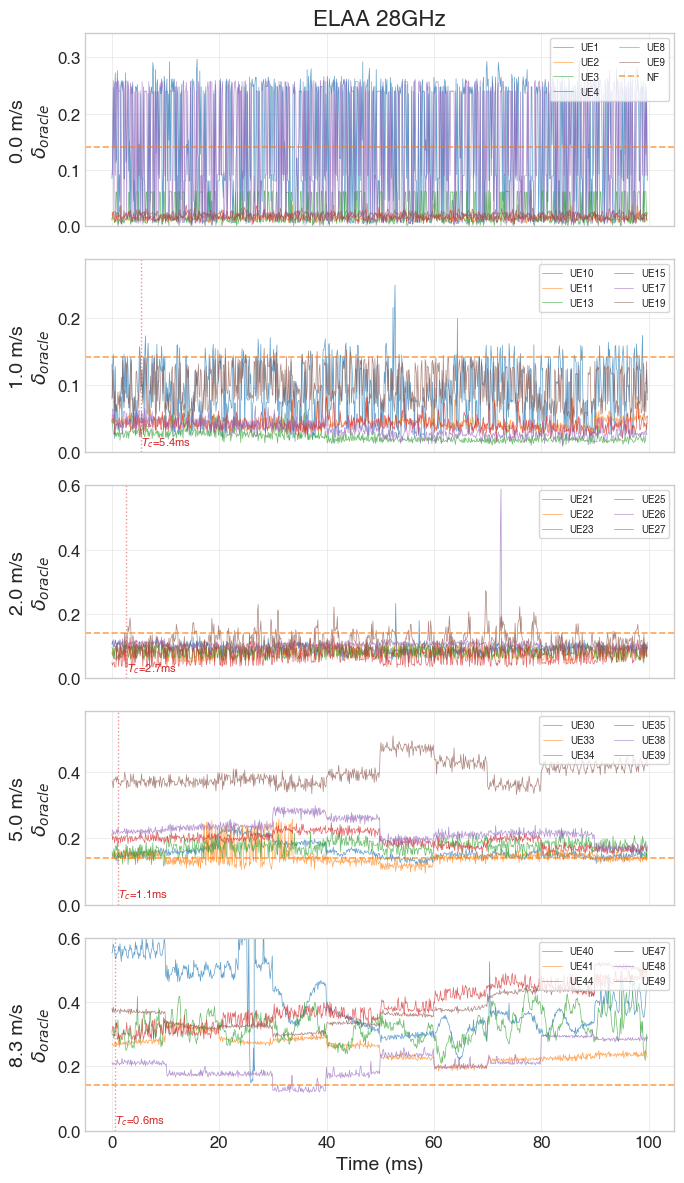

In [33]:
# Fig 2: Oracle $\delta$ time series — per speed group
# Load from cache if all_ue_data not in memory
import json as _json
from src.experiments.result_cache import CACHE_DIR, _decode_numpy

if not all_ue_data or all(v is None for v in all_ue_data.values()):
    print("[cache] Loading plot data from cache...")
    all_ue_data = {}
    for preset in PRESETS:
        cp = CACHE_DIR / f"plot_data_{preset}.json"
        if cp.exists():
            with open(cp) as f:
                pc = _json.load(f, object_hook=_decode_numpy)
            class _Cfg:
                slot_duration_s = pc["dt_ms"] / 1000
                frequency = pc["frequency"]
            ue_list = []
            for uid, ud in pc["ues"].items():
                ue_list.append({"uid": int(uid), "speed": ud["speed"], "spd": ud["spd"],
                    "d_oracle": np.array(ud["d_oracle"]), "d_ls": np.array(ud["d_ls"]),
                    "tau_sweep_ls": ud.get("tau_sweep_ls"),
                    "tau_sweep_oracle": ud.get("tau_sweep_oracle"), "r": ud.get("r", float("nan")), "theta": ud.get("theta", float("nan"))})
            all_ue_data[preset] = {"cfg": _Cfg(), "ue_list": ue_list}
            print(f"  {PRESET_LABELS.get(preset, preset)}: {len(ue_list)} UEs from cache")

# ── Plot ──

plot_config.setup()

n_speeds = len(SPEED_ORDER)
n_presets = len(PRESETS)
fig_w = 7 * n_presets
fig, axes = plt.subplots(n_speeds, n_presets, figsize=(fig_w, 2.4 * n_speeds),
                         sharex=True, squeeze=False)
dt_ms_map = {p: all_ue_data[p]["cfg"].slot_duration_s * 1000
             for p in PRESETS if p in all_ue_data}

SPEED_CMAP = plt.cm.viridis(np.linspace(0.1, 0.9, n_speeds))

for col, preset in enumerate(PRESETS):
    ud = all_ue_data.get(preset)
    if ud is None:
        for row in range(n_speeds):
            axes[row, col].text(0.5, 0.5, "No data", ha="center", va="center",
                                transform=axes[row, col].transAxes)
        continue

    groups = group_by_speed(ud["ue_list"])

    for row, spd_lbl in enumerate(SPEED_ORDER):
        ax = axes[row, col]
        for u in groups.get(spd_lbl, []):
            delta = u["d_oracle"]
            t_ms = np.arange(len(delta)) * dt_ms_map[preset]
            ax.plot(t_ms, delta, lw=0.5, alpha=0.7, label=f"UE{u['uid']}")

        ax.axhline(NOISE_FLOOR, color="tab:orange", ls="--", lw=1.2, alpha=0.7,
                   label="NF" if row == 0 else None)

        # Coherence time vline
        if preset in COHERENCE and spd_lbl in COHERENCE[preset]:
            T_c_slots = COHERENCE[preset][spd_lbl]
            if T_c_slots < 1e6:
                T_c_ms = T_c_slots * dt_ms_map[preset]
                ax.axvline(T_c_ms, color="tab:red", ls=":", lw=1, alpha=0.5)
                ax.text(T_c_ms * 1.02, 0.02, f"$T_c$={T_c_ms:.1f}ms",
                        fontsize=BASE.font_size_legend - 2, color="tab:red",
                        ha="left", va="bottom", transform=ax.get_xaxis_transform())

        y_max = min(0.6, ax.get_ylim()[1] * 1.1) if groups.get(spd_lbl) else 0.6
        ax.set_ylim(0, y_max)
        if row == 0:
            ax.set_title(PRESET_LABELS[preset])
        if col == 0:
            ax.set_ylabel(f"{spd_lbl} m/s\n$\\delta_{{oracle}}$")
        if row == n_speeds - 1:
            ax.set_xlabel("Time (ms)")
        ax.legend(fontsize=BASE.font_size_legend - 3, loc="upper right", ncol=2)

plt.tight_layout()
savefig(fig, "paper_fig2_delta_timeseries", Path("../../assets/plots"))
plt.show()
plt.close(fig)

## Fig 3: NMSE vs Threshold — noise floor is safe skip level

### LS Monitor Noise Floor Derivation

In OFDM systems, the LS channel estimate at subcarrier $k$ is:

$$\hat{H}_{\text{LS}}[k] = \frac{Y[k]}{X[k]} = H[k] + \frac{N[k]}{X[k]}$$

where $Y[k]$ is the received DMRS, $X[k]$ is the known pilot, $N[k] \sim \mathcal{CN}(0, \sigma^2_n)$ is AWGN.

The **Channel Estimation Error Variance** of the LS estimator is:

$$\sigma^2_{\text{CE}} = \mathbb{E}\left[|\hat{H}_{\text{LS}} - H|^2\right] = \frac{\sigma^2_n}{|X|^2} = \frac{\sigma^2_n}{E_p} = \frac{1}{\text{SNR}}$$

where $E_p = |X|^2$ is the pilot energy. At SNR = 20 dB: $\sigma^2_{\text{CE}} = 0.01$.

Now, the scheduling monitor computes the **normalized LS difference**:

$$\delta_{\text{LS}}(t) = \frac{\|\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1)\|}{\|\hat{\mathbf{h}}_{\text{LS}}(t-1)\|}$$

For a **static channel** ($\mathbf{h}(t) = \mathbf{h}(t-1)$), the numerator reduces to the difference of two independent noise vectors:

$$\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1) = \mathbf{n}(t) - \mathbf{n}(t-1)$$

where $\mathbf{n}(t), \mathbf{n}(t-1) \sim \mathcal{CN}(\mathbf{0}, \sigma^2_{\text{CE}} \mathbf{I})$ are i.i.d. The squared norm:

$$\mathbb{E}\left[\|\mathbf{n}(t) - \mathbf{n}(t-1)\|^2\right] = 2 \sigma^2_{\text{CE}} \cdot D = \frac{2D}{\text{SNR}}$$

where $D = N_{\text{ant}} \times N_{\text{sc}}$ is the total channel dimension. Meanwhile:

$$\mathbb{E}\left[\|\hat{\mathbf{h}}_{\text{LS}}\|^2\right] \approx \|\mathbf{h}\|^2 + \sigma^2_{\text{CE}} \cdot D \approx \|\mathbf{h}\|^2 \quad (\text{high SNR})$$

Therefore the **noise floor** of $\delta_{\text{LS}}$ is:

$$\boxed{\delta_{\text{floor}} = \sqrt{\frac{2}{\text{SNR}_{\text{linear}}}} \approx 0.141 \quad \text{at 20 dB}}$$

**Physical interpretation**: Even when the channel is perfectly static, the LS monitor reports $\delta \approx 0.14$ due to estimation noise. Any true channel variation with $\delta_{\text{oracle}} < \delta_{\text{floor}}$ is **masked by noise** and cannot be detected by the LS monitor.

**Implication for scheduling**: Setting $\tau = \delta_{\text{floor}}$ means the scheduler skips CE whenever the *observed* variation is below the noise floor. For static/slow UEs where $\delta_{\text{oracle}} \ll \delta_{\text{floor}}$, this is safe — the "variation" is entirely noise.

---

### Fig 3 해석: 속도별 NMSE vs $\tau$/NF 곡선

**x축**: $c = \tau/\text{NF}$. $c$가 클수록 skip threshold가 높아져 더 공격적으로 skip.

**스케줄링 규칙**: $\delta_{oracle}(t) > \tau$이면 full CE, 아니면 skip (이전 추정 재사용).

**관찰**: 고속 UE (빨간)일수록 NMSE 악화가 **오른쪽**에서 발생. 저속 UE (파란)는 **왼쪽**에서 먼저 악화.

**원인** (핵심 메커니즘):
- **정적 UE** ($v=0$): $\delta_{oracle} \approx 0$ → 어떤 $\tau$에서든 항상 skip. 채널이 안 변하니 skip이 정답. 오히려 noise averaging 효과로 NMSE < -20dB (full CE보다 좋음).
- **저속 UE** ($v=1\sim2$ m/s): $\delta_{oracle}$이 작음 (~0.001-0.01). $c \approx 0.03$만 넘어도 $\tau > \delta$ → 거의 항상 skip → 채널은 천천히 변하는데 outdated estimate 사용 → **일찍 NMSE 상승 시작**.
- **고속 UE** ($v=8.3$ m/s): $\delta_{oracle}$이 큼 (~0.1-0.3). $c \approx 1.5$ 되어야 $\tau > \delta$ → 그 전까지는 $\delta > \tau$라 **full CE를 계속 수행** → NMSE 유지 → $c > 1.5$에서야 skip이 시작되며 **늦게 NMSE 급등**.

**물리적 해석**: 빠른 UE는 채널 변화($\delta$)가 커서 skip threshold를 높여도 스케줄러가 "채널이 변했다"고 판단 → full CE 유지. 느린 UE는 $\delta$가 noise floor보다 작아서 조금만 threshold를 올려도 skip에 빠짐.

**$c=1$ (주황 점선)의 의미**: $\tau = \text{NF}$, 즉 "LS 추정 잡음 수준의 변화는 무시".
- 정적/저속 UE: $c=1$에서 이미 공격적 skip 중 → NMSE 소폭 상승하지만 수용 가능
- 고속 UE: $c=1$에서 여전히 full CE 위주 → skip gain이 적음

**결론**: $c=1$은 보수적 operating point. 저속 UE는 $c < 1$에서도 충분한 skip gain 확보 가능하고, 고속 UE는 $c > 1$까지 올려도 안전. Speed-adaptive $\tau(v)$로 최적화 여지 있음.


  Saved: ../../assets/plots/nmse_vs_tau_per_v.pdf
  Saved: ../../assets/plots/nmse_vs_tau_per_v.png


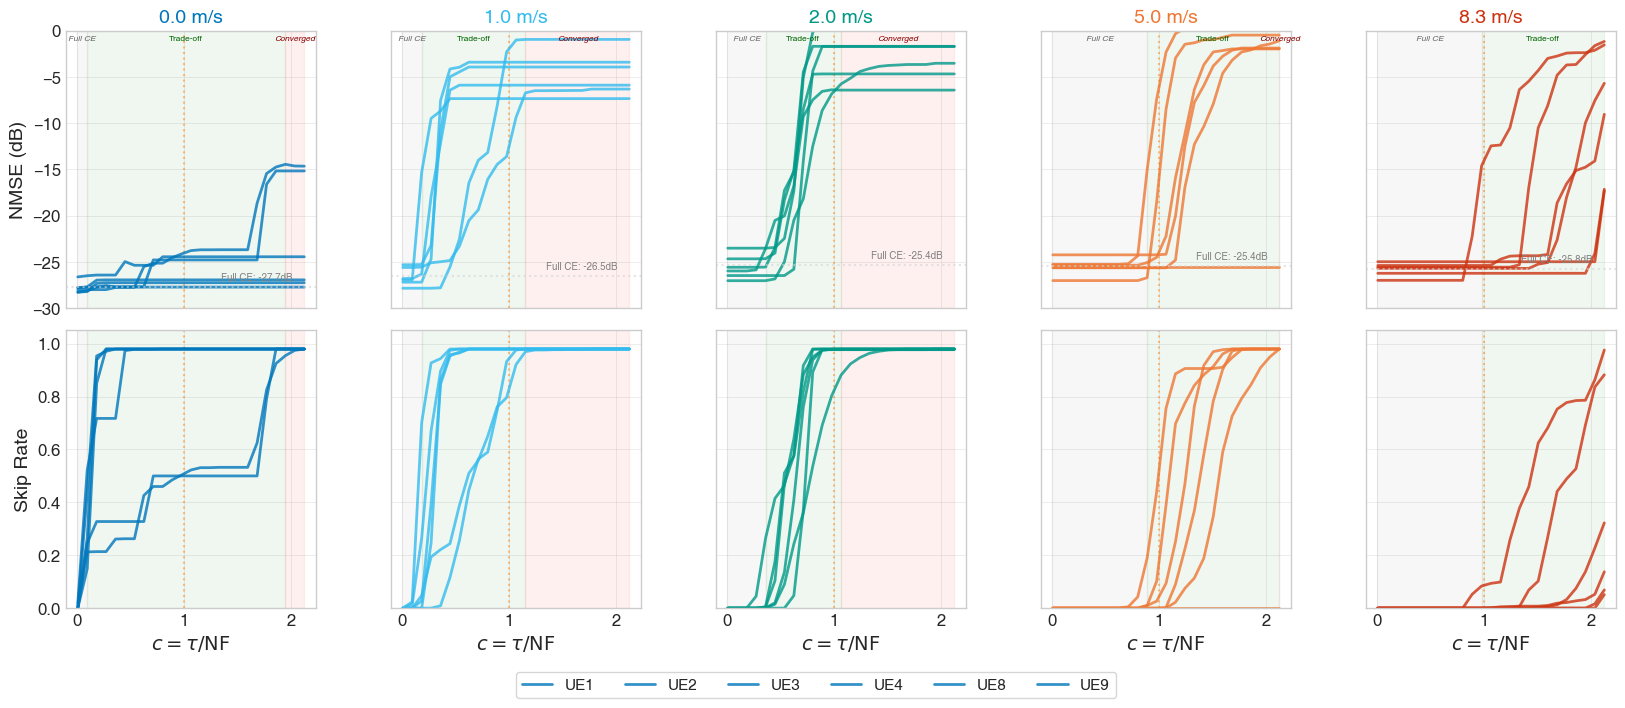

In [44]:
from src.experiments.plot_config import BASE, savefig
# Fig 3: NMSE + Skip Rate vs threshold — mixed (left) + per-speed (right)
thresholds = np.linspace(0.001, 0.3, 25).tolist()
plt.rcParams.update({"axes.labelsize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12})

# More vivid speed colors
_VIV_COLORS = {"0.0": "#0077BB", "1.0": "#33BBEE", "2.0": "#009988",
               "5.0": "#EE7733", "8.3": "#CC3311"}

for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue

    n_speeds = len(SPEED_ORDER)
    fig, axes = plt.subplots(2, n_speeds, figsize=(4 * n_speeds, 7.5),
                              sharex=True, gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08,
                                                         "wspace": 0.3})

    c_vals = [t / NOISE_FLOOR for t in thresholds]

    # ── Right columns: one per speed with zone shading ──
    groups = group_by_speed(ud["ue_list"])
    for si, spd_lbl in enumerate(SPEED_ORDER):
        col = si
        ax_n = axes[0, col]
        ax_s = axes[1, col]
        color = _VIV_COLORS.get(spd_lbl, "gray")

        # Per-speed 3 zones based on skip rate behavior
        all_nmses, all_srs = [], []
        for u in groups.get(spd_lbl, []):
            results = u["tau_sweep_oracle"]
            all_nmses.append([np.mean(r["nmse_arr"]) for r in results])
            all_srs.append([r["n_skip"] / r["total"] for r in results])
        if all_nmses:
            avg_nmse = np.mean(all_nmses, axis=0)
            avg_sr = np.mean(all_srs, axis=0)
            c_max = c_vals[-1]
            # Full CE → Trade-off: skip rate starts changing (> 1%)
            start_gen = (i for i, s in enumerate(avg_sr) if s > 0.01)
            start_idx = next(start_gen, None)
            # Trade-off → Converged: skip rate gradient flattens
            # (derivative < 5% of max derivative → stopped changing)
            grad = np.gradient(avg_sr, c_vals)
            max_grad = np.max(np.abs(grad))
            if max_grad > 0:
                flat_gen = (i for i in range(len(grad))
                            if i > (start_idx or 0) and avg_sr[i] > 0.01
                            and np.all(np.abs(grad[i:]) < 0.05 * max_grad))
                saturate_idx = next(flat_gen, None)
            else:
                saturate_idx = None

            if start_idx is None:
                # Never skips → entire range is Full CE
                for ax in [ax_n, ax_s]:
                    ax.axvspan(0, c_max, alpha=0.06, color="gray")
                ax_n.text(c_max / 2, -1, "Full CE\n(no skip opp.)",
                          fontsize=7, ha="center", color="dimgray", fontstyle="italic")
            elif saturate_idx is not None and saturate_idx <= start_idx:
                # Jumps straight to saturated → Full CE then Converged
                c_sat = c_vals[saturate_idx]
                for ax in [ax_n, ax_s]:
                    ax.axvspan(0, c_sat, alpha=0.06, color="gray")
                    ax.axvspan(c_sat, c_max, alpha=0.06, color="red")
                ax_n.text(c_sat / 2, -1, "Full CE", fontsize=6, ha="center",
                          color="dimgray", fontstyle="italic")
                ax_n.text((c_sat + c_max) / 2, -1, "Converged", fontsize=6, ha="center",
                          color="darkred", fontstyle="italic")
            elif saturate_idx is None:
                # Skip rate changes but never saturates → Full CE then Trade-off
                c_start = c_vals[start_idx]
                for ax in [ax_n, ax_s]:
                    ax.axvspan(0, c_start, alpha=0.06, color="gray")
                    ax.axvspan(c_start, c_max, alpha=0.06, color="green")
                ax_n.text(c_start / 2, -1, "Full CE", fontsize=6, ha="center",
                          color="dimgray", fontstyle="italic")
                ax_n.text((c_start + c_max) / 2, -1, "Trade-off", fontsize=6, ha="center",
                          color="darkgreen", fontweight="bold")
            else:
                # 3 zones: Full CE → Trade-off → Converged
                c_start = c_vals[start_idx]
                c_sat = c_vals[saturate_idx]
                for ax in [ax_n, ax_s]:
                    ax.axvspan(0, c_start, alpha=0.06, color="gray")
                    ax.axvspan(c_start, c_sat, alpha=0.06, color="green")
                    ax.axvspan(c_sat, c_max, alpha=0.06, color="red")
                ax_n.text(c_start / 2, -1, "Full CE", fontsize=6, ha="center",
                          color="dimgray", fontstyle="italic")
                ax_n.text((c_start + c_sat) / 2, -1, "Trade-off", fontsize=6, ha="center",
                          color="darkgreen", fontweight="bold")
                ax_n.text((c_sat + c_max) / 2, -1, "Converged", fontsize=6, ha="center",
                          color="darkred", fontstyle="italic")

        for ax in [ax_n, ax_s]:
            ax.axvline(1.0, color="tab:orange", ls=":", lw=1.5, alpha=0.5)

        for u in groups.get(spd_lbl, []):
            results = u["tau_sweep_oracle"]
            c_vals = [t / NOISE_FLOOR for t in thresholds]
            nmses = [10 * np.log10(max(np.mean(r["nmse_arr"]), 1e-30)) for r in results]
            srs = [r["n_skip"] / r["total"] for r in results]
            ax_n.plot(c_vals, nmses, "-", color=color, lw=2, alpha=0.8, label=f"UE{u['uid']}")
            ax_s.plot(c_vals, srs, "-", color=color, lw=2, alpha=0.8)

        ax_n.set_ylim(-30, 0)
        if si == 0:
            ax_n.set_ylabel("NMSE (dB)")
        ax_n.set_title(f"{spd_lbl} m/s", fontsize=14, color=color, fontweight="bold")
        # Full CE baseline: NMSE at c≈0 (every slot CE)
        if all_nmses:
            full_ce_db = 10 * np.log10(max(np.mean([nm[0] for nm in all_nmses]), 1e-30))
            ax_n.axhline(full_ce_db, color="lightgray", ls=":", alpha=0.6, lw=1.5)
            ax_n.text(c_vals[-1]*0.95, full_ce_db+0.5, f"Full CE: {full_ce_db:.1f}dB",
                      fontsize=7, ha="right", va="bottom", color="gray")
        if si > 0:
            ax_n.set_yticklabels([])
            ax_s.set_yticklabels([])
        ax_s.set_ylim(0, 1.05)
        if si == 0:
            ax_s.set_ylabel("Skip Rate")
        ax_s.set_xlabel("$c = \\tau / \\mathrm{NF}$")

    # Shared horizontal legend below figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=n_speeds + 1,
               fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))

    # plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    savefig(fig, "nmse_vs_tau_per_v", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)

## Fig 3c: Trade-off Zone Dependency — Speed vs Position

**Question**: Trade-off zone (c range where skip rate is changing) clearly depends on speed.
But does it also depend on UE *position* (r, θ relative to BS)?

- If position matters → scheduling must be location-aware (more complex)
- If only speed matters → speed-adaptive threshold is sufficient

**Method**: For each UE, extract trade-off zone boundaries (c_start, c_sat) from binary skip sweep.
Plot zone width and boundaries against (v, r, θ) to identify which variables are significant.

  ELAA 28GHz: 2370 windows (30 UEs × 79 windows)
  Saved: ../../assets/plots/tradeoff_zone_vs_position.pdf
  Saved: ../../assets/plots/tradeoff_zone_vs_position.png


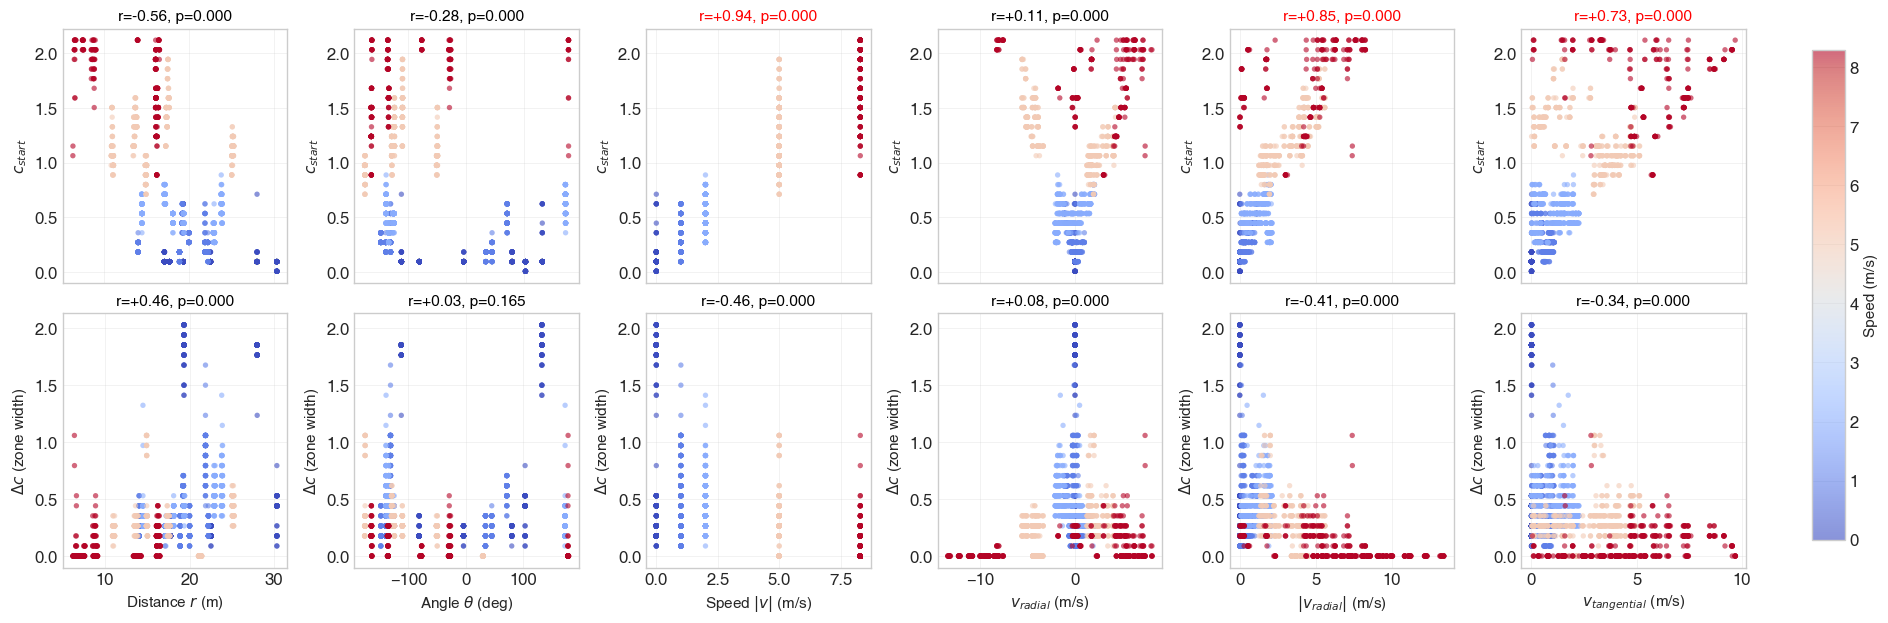


Local window correlation (W=10 slots) — ELAA 28GHz

  c_start:
    vs          r: r=-0.555  p=0.0000 ***
    vs      theta: r=-0.277  p=0.0000 ***
    vs      speed: r=+0.943  p=0.0000 ***
    vs   v_radial: r=+0.115  p=0.0000 ***
    vs    |v_rad|: r=+0.846  p=0.0000 ***
    vs     v_tang: r=+0.726  p=0.0000 ***

  zone_width:
    vs          r: r=+0.416  p=0.0000 ***
    vs      theta: r=+0.075  p=0.0006 ***
    vs      speed: r=-0.358  p=0.0000 ***
    vs   v_radial: r=-0.060  p=0.0065 **
    vs    |v_rad|: r=-0.302  p=0.0000 ***
    vs     v_tang: r=-0.276  p=0.0000 ***


In [45]:
from src.experiments.plot_config import BASE, savefig
from scipy import stats as _st

# ═══ Fig 3c: Trade-off zone vs (r, θ, v_radial, v_tangential) ═══
# LOCAL windows: split trajectory into short segments, compute per-window features + zone params

WINDOW = 10  # slots per window (50 × 0.125ms = 6.25ms)

for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue
    cfg = ud["cfg"]

    # Load trajectory for position/velocity per window
    from src.ce_skip import ExperimentConfig
    _cfg = ExperimentConfig.from_preset(preset)
    traj = np.load(Path(_cfg.trajectory_dir) / "trajectories.npz")
    positions = traj["positions"]    # (T, N_UE, 3)
    velocities = traj["velocities"]  # (T, N_UE, 2)
    from src.config import SceneConfig
    scene_cfg = SceneConfig.from_preset(preset)
    bs_positions = scene_cfg.bs_positions

    thresholds = np.linspace(0.001, 0.3, 25)
    c_vals = thresholds / NOISE_FLOOR

    records = []
    for u in ud["ue_list"]:
        uid, bs_id = u["uid"], u["bs_id"]
        d_oracle = u["d_oracle"]  # (T-1,)
        T_delta = len(d_oracle)
        bs_pos = np.array(bs_positions[bs_id])[:2]

        n_windows = T_delta // WINDOW
        for wi in range(n_windows):
            t0 = wi * WINDOW
            t1 = t0 + WINDOW
            d_win = d_oracle[t0:t1]

            # Local position/velocity at window midpoint
            t_mid = t0 + WINDOW // 2
            ue_pos = positions[t_mid, uid, :2]
            rel = ue_pos - bs_pos
            r_local = float(np.linalg.norm(rel))
            theta_local = float(np.degrees(np.arctan2(rel[1], rel[0])))

            v_local = velocities[t0:t1, uid, :].mean(axis=0)
            r_hat = rel / r_local if r_local > 1e-6 else np.zeros(2)
            vr = float(np.dot(v_local, r_hat))
            v_mag = float(np.linalg.norm(v_local))
            vt = float(np.sqrt(max(v_mag**2 - vr**2, 0)))

            # Per-window skip rate for each c
            srs = np.array([(d_win < tau).mean() for tau in thresholds])

            # c_start: first c where skip rate > 1%
            start_idx = next((i for i, s in enumerate(srs) if s > 0.01), None)
            # Saturation: gradient < 5% of max
            grad = np.gradient(srs, c_vals)
            max_grad = np.max(np.abs(grad))
            sat_idx = None
            if max_grad > 0 and start_idx is not None:
                sat_idx = next((i for i in range(len(grad))
                               if i > start_idx and srs[i] > 0.01
                               and np.all(np.abs(grad[i:]) < 0.05 * max_grad)), None)

            c_start = c_vals[start_idx] if start_idx is not None else np.nan
            c_sat = c_vals[sat_idx] if sat_idx is not None else c_vals[-1]
            zone_width = c_sat - c_start if start_idx is not None else 0.0

            records.append({
                "uid": uid, "speed": u["speed"], "window": wi,
                "r": r_local, "theta": theta_local,
                "v_radial": vr, "v_tangential": vt,
                "c_start": c_start, "zone_width": zone_width,
            })

    if not records: continue
    print(f"  {PRESET_LABELS[preset]}: {len(records)} windows ({len(ud['ue_list'])} UEs × {n_windows} windows)")

    rs = np.array([r["r"] for r in records])
    thetas = np.array([r["theta"] for r in records])
    v_rads = np.array([r["v_radial"] for r in records])
    v_tangs = np.array([r["v_tangential"] for r in records])
    abs_v_rads = np.abs(v_rads)
    speeds = np.array([r["speed"] for r in records])
    c_starts = np.array([r["c_start"] for r in records])
    widths = np.array([r["zone_width"] for r in records])

    # ── Plot ──
    fig, axes = plt.subplots(2, 6, figsize=(22, 7))
    axes[1, 2].sharex(axes[0, 2])
    axes[1, 3].sharex(axes[0, 3])
    axes[1, 4].sharex(axes[0, 4])
    axes[1, 5].sharex(axes[0, 5])
    x_vars = [rs, thetas, speeds, v_rads, abs_v_rads, v_tangs]
    x_labels = ["Distance $r$ (m)", "Angle $\\theta$ (deg)", "Speed $|v|$ (m/s)", "$v_{radial}$ (m/s)", "$|v_{radial}|$ (m/s)", "$v_{tangential}$ (m/s)"]

    for ax, xvar, xlabel in zip(axes[0], x_vars, x_labels):
        sc = ax.scatter(xvar, c_starts, c=speeds, cmap="coolwarm", s=15, alpha=0.6, edgecolors="none", zorder=3)
        ax.tick_params(labelbottom=False)
        ax.set_ylabel("$c_{start}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        _mask = ~np.isnan(xvar) & ~np.isnan(c_starts)
        if _mask.sum() >= 3:
            _r, _p = _st.pearsonr(xvar[_mask], c_starts[_mask])
            _bold = "bold" if abs(_r) >= 0.5 else "normal"
            _color = "red" if abs(_r) >= 0.7 else "black"
            ax.set_title(f"r={_r:+.2f}, p={_p:.3f}", fontsize=11, fontweight=_bold, color=_color)

    for ax, xvar, xlabel in zip(axes[1], x_vars, x_labels):
        sc = ax.scatter(xvar, widths, c=speeds, cmap="coolwarm", s=15, alpha=0.6, edgecolors="none", zorder=3)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("$\\Delta c$ (zone width)", fontsize=11)
        ax.grid(True, alpha=0.3)
        _mask = ~np.isnan(xvar) & ~np.isnan(widths)
        if _mask.sum() >= 3:
            _r, _p = _st.pearsonr(xvar[_mask], widths[_mask])
            _bold = "bold" if abs(_r) >= 0.5 else "normal"
            _color = "red" if abs(_r) >= 0.7 else "black"
            ax.set_title(f"r={_r:+.2f}, p={_p:.3f}", fontsize=11, fontweight=_bold, color=_color)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Speed (m/s)", fontsize=11)

    fig.subplots_adjust(right=0.89, hspace=0.12, wspace=0.3)
    savefig(fig, "tradeoff_zone_vs_position", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)

    # ── Correlation summary ──
    print(f"\n{'='*60}")
    print(f"Local window correlation (W={WINDOW} slots) — {PRESET_LABELS[preset]}")
    print(f"{'='*60}")
    valid = ~np.isnan(c_starts)
    for target_name, target in [("c_start", c_starts), ("zone_width", widths)]:
        print(f"\n  {target_name}:")
        for var_name, var in [("r", rs), ("theta", thetas), ("speed", speeds), ("v_radial", v_rads), ("|v_rad|", abs_v_rads), ("v_tang", v_tangs)]:
            mask = valid & ~np.isnan(var)
            if mask.sum() < 3: continue
            r_val, p_val = _st.pearsonr(var[mask], target[mask])
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            print(f"    vs {var_name:>10}: r={r_val:+.3f}  p={p_val:.4f} {sig}")

## Fig 3d: 속도 추정 기반 Adaptive τ

### 배경
Fig 3에서 확인한 핵심 관찰: **속도가 다르면 최적 τ도 다르다.**
- 정적 UE (0 m/s): 큰 τ로 대부분 skip 가능 → overhead 절감
- 고속 UE (8.3 m/s): 작은 τ로 자주 CE 해야 NMSE 유지

현재 방식(Fixed τ)은 모든 UE에 동일한 τ를 적용하므로, 어느 속도에서든 최적이 아님.

### 실험 설계
**3가지 전략 비교:**

| 전략 | τ 결정 방법 | 속도 정보 | 의미 |
|------|-----------|----------|------|
| **Fixed τ** (baseline) | τ = NF × 1.0 (c=1 고정) | 없음 | 현재 방식의 한계 |
| **Adaptive τ** (proposed) | δ history → Doppler → v 추정 → τ*(v) | 추정 | 실제 구현 가능한 방식 |
| **Oracle τ** (upper bound) | 실제 속도 v_true → τ*(v) | 완벽 | 이론적 상한 |

### 구현 (pipeline.py)
```
δ[t] → EMA smoothing → f_d = δ/(2π·Δt) → v = f_d·c/f_c → T_c(v) → τ*(v)
```

1. **Doppler 추정**: δ의 EMA로 노이즈 제거 후, `f_d ≈ δ / (2π·Δt)` 관계로 Doppler spread 추정
2. **속도 변환**: `v = f_d · c / f_c` (carrier frequency 이용)
3. **Coherence time**: `T_c = λ / (2v)` → slot 단위로 변환
4. **τ 매핑**: T_c가 길수록(느린 UE) → 높은 c, T_c가 짧을수록(빠른 UE) → 낮은 c
   - c ∈ [c_min=0.3, c_max=3.0], sigmoid-like mapping

### 해석 방법
- **NMSE 비교** (왼쪽): Adaptive가 Fixed보다 낮으면 속도 적응이 효과적
  - Oracle과의 gap = 속도 추정 오차로 인한 손실
  - Full CE와의 gap = skip으로 인한 품질 저하
- **Skip Rate 비교** (오른쪽): 같은 NMSE에서 skip rate이 높을수록 좋음
  - 정적 UE에서 Adaptive > Fixed면 불필요한 CE를 줄인 것
  - 고속 UE에서 Adaptive < Fixed면 필요한 CE를 더 한 것 (품질 보호)

### 기대 결과
- 정적/저속 UE: Adaptive가 Fixed보다 skip rate 높고 NMSE 유사 → overhead 절감
- 고속 UE: Adaptive가 Fixed보다 NMSE 낮음 (CE를 더 자주 해서 품질 보호)
- Adaptive ≈ Oracle이면 δ 기반 속도 추정이 충분히 정확하다는 의미

  Loaded train LUT: train_lut_delta_28g.json (15 UEs)
  Saved: ../../assets/plots/paper_fig3d_adaptive_tau.pdf
  Saved: ../../assets/plots/paper_fig3d_adaptive_tau.png


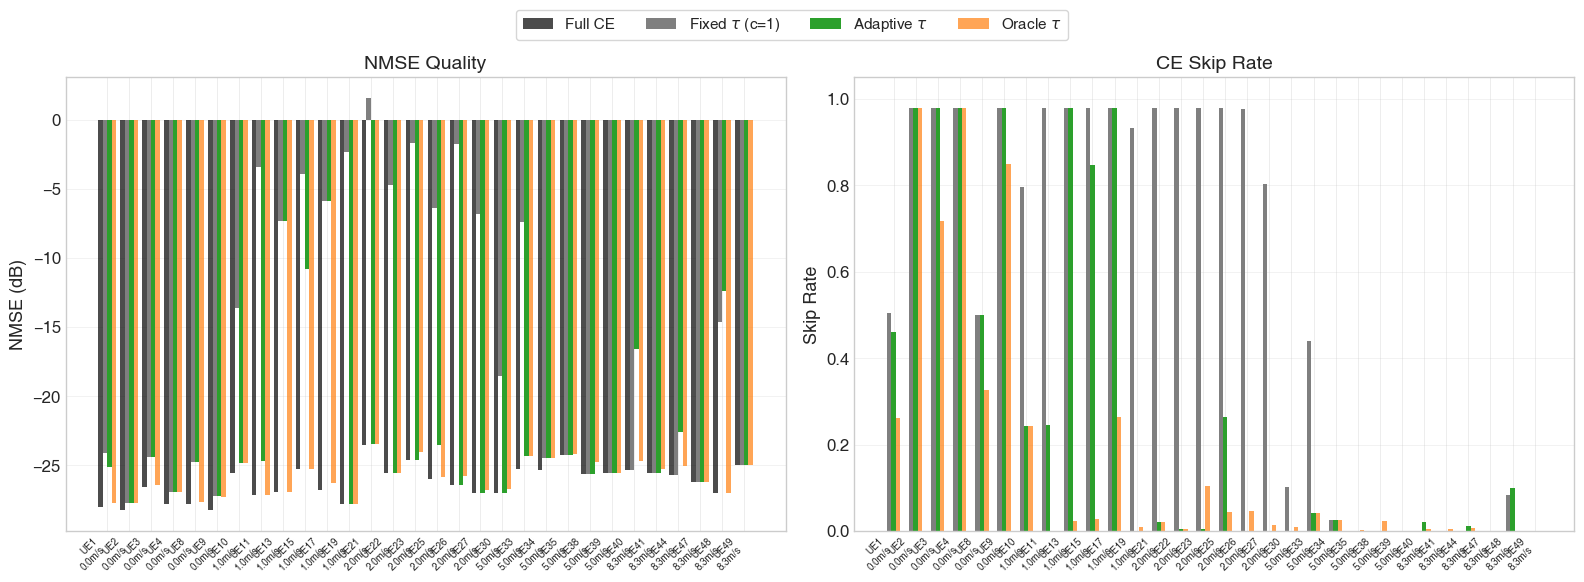


    UE  Speed  v_est c_adpt c_orc |    Full   Fixed   Adapt  Oracle | SR_fix SR_adp SR_orc
----------------------------------------------------------------------------------------------------
UE  1   0.0    2.0  0.81  0.54  |  -28.0   -24.1   -25.1   -27.7  | 50.4%  46.0%  26.2%
UE  2   0.0    0.2  2.12  2.12  |  -28.3   -27.7   -27.7   -27.7  | 98.0%  98.0%  98.0%
UE  3   0.0    0.3  1.99  0.36  |  -26.6   -24.4   -24.4   -26.4  | 98.0%  98.0%  71.8%
UE  4   0.0    0.2  2.12  2.12  |  -27.8   -26.9   -26.9   -26.9  | 98.0%  98.0%  98.0%
UE  8   0.0    1.9  0.76  0.62  |  -27.8   -24.8   -24.8   -27.7  | 50.0%  50.0%  32.8%
UE  9   0.0    0.3  2.12  0.18  |  -28.3   -27.2   -27.2   -27.3  | 98.0%  98.0%  85.0%
UE 10   1.0    1.2  0.44  0.45  |  -25.6   -13.6   -24.8   -24.8  | 79.6%  24.4%  24.4%
UE 11   1.0    0.6  0.24  0.18  |  -27.2    -3.4   -24.7   -27.2  | 98.0%  24.6%   0.0%
UE 13   1.0    0.3  2.12  0.10  |  -26.9    -7.3    -7.3   -26.9  | 98.0%  98.0%   2.4%
UE 15   1.0    

In [60]:
from src.experiments.plot_config import BASE, savefig
from src.experiments.pipeline import _empirical_optimal_c, _estimate_speed_from_deltas
from scipy.interpolate import interp1d

# ═══ Fig 3d: Fixed τ vs Adaptive τ vs Oracle τ ═══
# Reuse tau_sweep_oracle results — no recomputation needed.

for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue
    cfg = ud["cfg"]
    dt_s = cfg.slot_duration_s
    freq = cfg.frequency

    # Load delta→c LUT from train UEs (leak-free)
    import json as _json
    _lut_map = {"munich_elaa_m_1k_28g": "28g", "munich_elaa_m_1k_15g": "15g", "munich_5g_mimo_3g5": "5g"}
    _lut_path = Path("../../assets/results/paper_cache") / f"train_lut_delta_{_lut_map.get(preset, '28g')}.json"
    with open(_lut_path) as _f:
        _lut_data = _json.load(_f)
    _lut_sorted = sorted(_lut_data, key=lambda x: x["med_delta"])
    _deltas_lut = np.array([d["med_delta"] for d in _lut_sorted])
    _copt_lut = np.array([d["c_opt"] for d in _lut_sorted])
    delta_to_c = interp1d(_deltas_lut, _copt_lut, kind="linear",
                          bounds_error=False, fill_value=(_copt_lut[0], _copt_lut[-1]))
    print(f"  Loaded train LUT: {_lut_path.name} ({len(_lut_data)} UEs)")

    # Extract results from tau sweep (already computed with DL-CE)
    thresholds_oracle = np.array(TAU_ORACLE)
    c_vals_oracle = thresholds_oracle / NOISE_FLOOR

    records = []
    for u in ud["ue_list"]:
        sweep = u["tau_sweep_oracle"]
        nmses_sweep = np.array([np.mean(r["nmse_arr"]) for r in sweep])
        srs_sweep = np.array([r["n_skip"] / r["total"] for r in sweep])

        # Full CE: first point (c≈0, no skip)
        nmse_full = nmses_sweep[0]

        # Fixed τ (c=1): find closest c to 1.0
        c1_idx = np.argmin(np.abs(c_vals_oracle - 1.0))
        nmse_fixed = nmses_sweep[c1_idx]
        sr_fixed = srs_sweep[c1_idx]

        # Oracle τ: empirical optimal c
        c_opt = _empirical_optimal_c(sweep, NOISE_FLOOR, nmse_margin_db=1.0)
        c_opt_idx = np.argmin(np.abs(c_vals_oracle - c_opt))
        nmse_oracle = nmses_sweep[c_opt_idx]
        sr_oracle = srs_sweep[c_opt_idx]

        # Adaptive τ: observe delta directly, lookup c (no speed estimation)
        from src.experiments.pipeline import _estimate_speed_from_deltas
        v_est = _estimate_speed_from_deltas(u["d_oracle"], dt_s, freq, ema_alpha=0.3)
        # Delta-based: use EMA-smoothed delta for LUT lookup
        ema_alpha = 0.3
        d = u["d_oracle"]
        ema = np.empty_like(d); ema[0] = d[0]
        for _t in range(1, len(d)): ema[_t] = ema_alpha * d[_t] + (1 - ema_alpha) * ema[_t-1]
        c_adapt = float(delta_to_c(np.median(ema)))
        c_adapt_idx = np.argmin(np.abs(c_vals_oracle - c_adapt))
        nmse_adapt = nmses_sweep[c_adapt_idx]
        sr_adapt = srs_sweep[c_adapt_idx]

        records.append({
            "uid": u["uid"], "speed": u["speed"], "spd": u.get("spd", f"{u['speed']:.1f}"),
            "nmse_full_ce": 10 * np.log10(max(nmse_full, 1e-30)),
            "nmse_fixed": 10 * np.log10(max(nmse_fixed, 1e-30)),
            "nmse_adapt": 10 * np.log10(max(nmse_adapt, 1e-30)),
            "nmse_oracle": 10 * np.log10(max(nmse_oracle, 1e-30)),
            "sr_fixed": sr_fixed, "sr_adapt": sr_adapt, "sr_oracle": sr_oracle,
            "c_oracle": c_opt, "c_adapt": c_adapt,
            "v_est_mean": float(v_est.mean()),
        })

    # ── Plot ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    n = len(records)
    x = np.arange(n)
    w = 0.2
    labels = [f"UE{r['uid']}\n{r['spd']}m/s" for r in records]

    ax = axes[0]
    ax.bar(x - 1.5*w, [r["nmse_full_ce"] for r in records], w, label="Full CE", color="black", alpha=0.7)
    ax.bar(x - 0.5*w, [r["nmse_fixed"] for r in records], w, label=r"Fixed $\tau$ (c=1)", color="tab:gray")
    ax.bar(x + 0.5*w, [r["nmse_adapt"] for r in records], w, label=r"Adaptive $\tau$", color="tab:green")
    ax.bar(x + 1.5*w, [r["nmse_oracle"] for r in records], w, label=r"Oracle $\tau$", color="tab:orange", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("NMSE (dB)", fontsize=13)
    ax.set_title("NMSE Quality", fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    ax = axes[1]
    ax.bar(x - w, [r["sr_fixed"] for r in records], w, label=r"Fixed $\tau$ (c=1)", color="tab:gray")
    ax.bar(x,     [r["sr_adapt"] for r in records], w, label=r"Adaptive $\tau$", color="tab:green")
    ax.bar(x + w, [r["sr_oracle"] for r in records], w, label=r"Oracle $\tau$", color="tab:orange", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("Skip Rate", fontsize=13)
    ax.set_title("CE Skip Rate", fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", ncol=4,
               fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    savefig(fig, "paper_fig3d_adaptive_tau", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)

    # Summary table
    print(f"\n{'UE':>6} {'Speed':>6} {'v_est':>6} {'c_adpt':>5} {'c_orc':>5} | {'Full':>7} {'Fixed':>7} {'Adapt':>7} {'Oracle':>7} | {'SR_fix':>6} {'SR_adp':>6} {'SR_orc':>6}")
    print("-" * 100)
    for r in records:
        print(f"UE{r['uid']:>3} {r['speed']:>5.1f}  {r['v_est_mean']:>5.1f}  {r['c_adapt']:>4.2f}  {r['c_oracle']:>4.2f}  | "
              f"{r['nmse_full_ce']:>6.1f}  {r['nmse_fixed']:>6.1f}  {r['nmse_adapt']:>6.1f}  {r['nmse_oracle']:>6.1f}  | "
              f"{r['sr_fixed']:>5.1%}  {r['sr_adapt']:>5.1%}  {r['sr_oracle']:>5.1%}")

    # Per-UE Adaptive vs Oracle comparison
    print(f"\n{'='*80}")
    print(f"Adaptive vs Oracle per UE — {PRESET_LABELS[preset]}")
    print(f"{'='*80}")
    print(f"{'UE':>5} {'Spd':>4} | {'c_adpt':>6} {'c_orc':>6} | {'NMSE_A':>7} {'NMSE_O':>7} {'gap':>5} | {'SR_A':>5} {'SR_O':>5} | {'verdict'}")
    print("-" * 80)
    for r in records:
        gap = r['nmse_adapt'] - r['nmse_oracle']
        if gap > 3:
            verdict = "!! FAIL"
        elif gap > 1:
            verdict = "~  OK"
        else:
            verdict = "=  MATCH"
        print(f"UE{r['uid']:>3} {r['speed']:>4.1f} | {r['c_adapt']:>6.2f} {r['c_oracle']:>6.2f} | "
              f"{r['nmse_adapt']:>7.1f} {r['nmse_oracle']:>7.1f} {gap:>+5.1f} | "
              f"{r['sr_adapt']:>4.0%} {r['sr_oracle']:>4.0%} | {verdict}")


Per-speed summary — ELAA 28GHz
 Speed   N |  Full CE    Fixed    Adapt   Oracle | SR_fix SR_adp SR_orc | FAIL
------------------------------------------------------------------------------------------
  0.0    6 |   -27.8    -25.9    -26.0    -27.3  | 82.1%  81.3%  68.6%  |   0/6
  1.0    6 |   -26.6     -6.1    -16.9    -26.4  | 94.1%  54.9%   9.5%  |   3/6
  2.0    6 |   -25.5     -3.3    -25.1    -25.2  | 95.0%   4.9%   3.9%  |   0/6
  5.0    6 |   -25.5    -21.0    -25.2    -25.0  |  9.4%   1.1%   1.7%  |   0/6
  8.3    6 |   -25.8    -23.7    -21.4    -25.5  |  1.4%   2.2%   0.3%  |   2/6
------------------------------------------------------------------------------------------
   ALL  30 |   -26.2    -16.0    -22.9    -25.9  | 56.4%  28.9%  16.8%  |   5/30
  Saved: ../../assets/plots/adaptive_tau.pdf
  Saved: ../../assets/plots/adaptive_tau.png


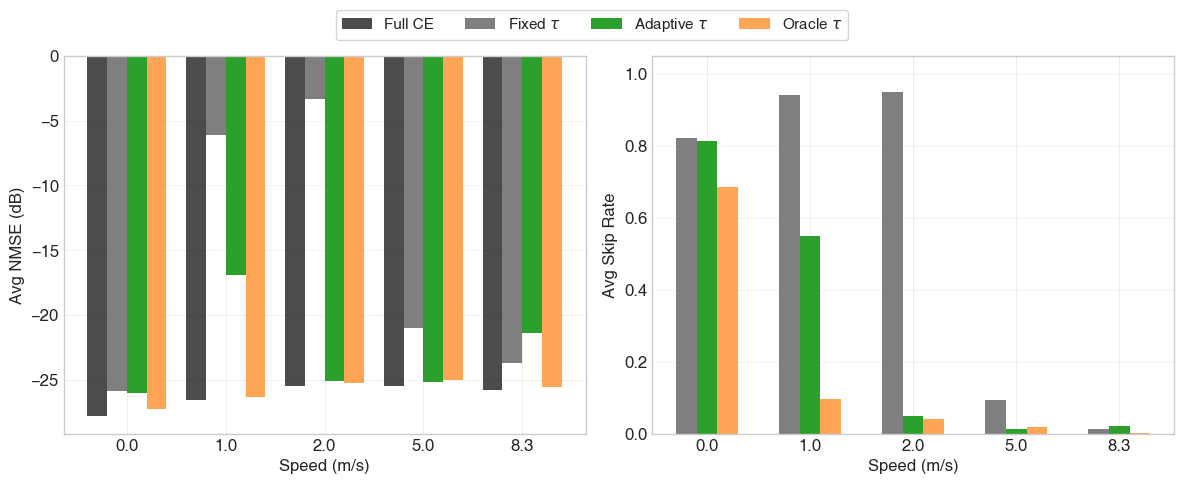

In [62]:
# ═══ Fig 3d summary: per-speed aggregated comparison ═══
from collections import defaultdict

for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue

    # Group records by speed
    speed_groups = defaultdict(list)
    for r in records:
        speed_groups[r["speed"]].append(r)

    print(f"\n{'='*90}")
    print(f"Per-speed summary — {PRESET_LABELS[preset]}")
    print(f"{'='*90}")
    print(f"{'Speed':>6} {'N':>3} | {'Full CE':>8} {'Fixed':>8} {'Adapt':>8} {'Oracle':>8} | {'SR_fix':>6} {'SR_adp':>6} {'SR_orc':>6} | {'FAIL':>4}")
    print("-" * 90)

    all_speeds = sorted(speed_groups.keys())
    summary_rows = []
    for spd in all_speeds:
        grp = speed_groups[spd]
        n = len(grp)
        avg = lambda key: np.mean([r[key] for r in grp])
        n_fail = sum(1 for r in grp if r["nmse_adapt"] - r["nmse_oracle"] > 3)
        row = {
            "speed": spd, "n": n,
            "full": avg("nmse_full_ce"), "fixed": avg("nmse_fixed"),
            "adapt": avg("nmse_adapt"), "oracle": avg("nmse_oracle"),
            "sr_fix": avg("sr_fixed"), "sr_adp": avg("sr_adapt"), "sr_orc": avg("sr_oracle"),
            "n_fail": n_fail,
        }
        summary_rows.append(row)
        print(f"{spd:>5.1f}  {n:>3} | {row['full']:>7.1f}  {row['fixed']:>7.1f}  {row['adapt']:>7.1f}  {row['oracle']:>7.1f}  | "
              f"{row['sr_fix']:>5.1%}  {row['sr_adp']:>5.1%}  {row['sr_orc']:>5.1%}  | {n_fail:>3}/{n}")

    # Overall
    all_r = [r for grp in speed_groups.values() for r in grp]
    n_total = len(all_r)
    n_fail_total = sum(1 for r in all_r if r["nmse_adapt"] - r["nmse_oracle"] > 3)
    print("-" * 90)
    print(f"{'ALL':>6} {n_total:>3} | {np.mean([r['nmse_full_ce'] for r in all_r]):>7.1f}  "
          f"{np.mean([r['nmse_fixed'] for r in all_r]):>7.1f}  "
          f"{np.mean([r['nmse_adapt'] for r in all_r]):>7.1f}  "
          f"{np.mean([r['nmse_oracle'] for r in all_r]):>7.1f}  | "
          f"{np.mean([r['sr_fixed'] for r in all_r]):>5.1%}  "
          f"{np.mean([r['sr_adapt'] for r in all_r]):>5.1%}  "
          f"{np.mean([r['sr_oracle'] for r in all_r]):>5.1%}  | "
          f"{n_fail_total:>3}/{n_total}")

    # Bar chart: speed-grouped
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(all_speeds))
    w = 0.2
    labels = [f"{s:.1f}" for s in all_speeds]

    ax = axes[0]
    ax.bar(x - 1.5*w, [r["full"] for r in summary_rows], w, label="Full CE", color="black", alpha=0.7)
    ax.bar(x - 0.5*w, [r["fixed"] for r in summary_rows], w, label=r"Fixed $\tau$", color="tab:gray")
    ax.bar(x + 0.5*w, [r["adapt"] for r in summary_rows], w, label=r"Adaptive $\tau$", color="tab:green")
    ax.bar(x + 1.5*w, [r["oracle"] for r in summary_rows], w, label=r"Oracle $\tau$", color="tab:orange", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel("Speed (m/s)", fontsize=12)
    ax.set_ylabel("Avg NMSE (dB)", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    ax = axes[1]
    ax.bar(x - w, [r["sr_fix"] for r in summary_rows], w, label=r"Fixed $\tau$", color="tab:gray")
    ax.bar(x,     [r["sr_adp"] for r in summary_rows], w, label=r"Adaptive $\tau$", color="tab:green")
    ax.bar(x + w, [r["sr_orc"] for r in summary_rows], w, label=r"Oracle $\tau$", color="tab:orange", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel("Speed (m/s)", fontsize=12)
    ax.set_ylabel("Avg Skip Rate", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", ncol=4,
               fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    savefig(fig, "adaptive_tau", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)

  Saved: ../../assets/plots/fig5_tradeoff.pdf
  Saved: ../../assets/plots/fig5_tradeoff.png


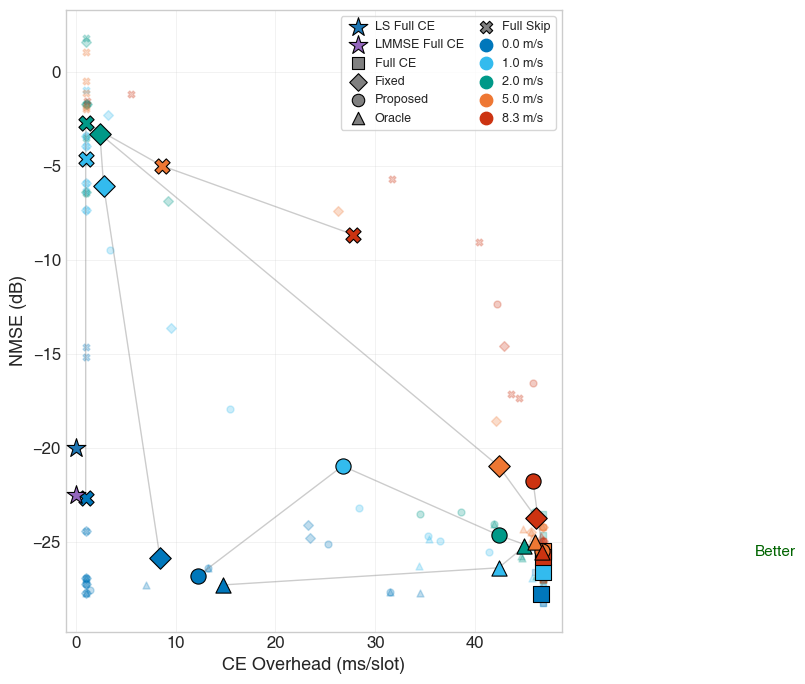


DL-CE inference: 46.7 ms/slot

 Speed | Method          NMSE  OH(ms)    Save
---------------------------------------------
  0.0 | Full CE       -27.8   46.6    0.1ms
  0.0 | Fixed         -25.9    8.4   38.3ms
  0.0 | Proposed      -26.8   12.2   34.5ms
  0.0 | Oracle        -27.3   14.7   32.0ms

  1.0 | Full CE       -26.6   46.8   -0.1ms
  1.0 | Fixed          -6.1    2.8   43.9ms
  1.0 | Proposed      -21.0   26.7   20.0ms
  1.0 | Oracle        -26.4   42.3    4.4ms

  2.0 | Full CE       -25.5   46.8   -0.1ms
  2.0 | Fixed          -3.3    2.4   44.3ms
  2.0 | Proposed      -24.7   42.4    4.3ms
  2.0 | Oracle        -25.2   44.9    1.8ms

  5.0 | Full CE       -25.5   46.8   -0.1ms
  5.0 | Fixed         -21.0   42.4    4.3ms
  5.0 | Proposed      -25.5   46.7   -0.0ms
  5.0 | Oracle        -25.0   46.0    0.7ms

  8.3 | Full CE       -25.8   46.8   -0.1ms
  8.3 | Fixed         -23.7   46.1    0.6ms
  8.3 | Proposed      -21.8   45.8    0.9ms
  8.3 | Oracle        -25.5   46.6  

In [90]:
# ═══ Fig 5: NMSE vs Skip Rate trade-off (single plot) ═══
from src.experiments.pipeline import _empirical_optimal_c
from scipy.interpolate import interp1d
from collections import defaultdict
import json as _json

CE_TIMES = {"LS": 0.0, "LMMSE": 0.05, "DL-CE": 46.7, "Delta monitor": 0.07}
_lut_map = {"munich_elaa_m_1k_28g": "28g", "munich_elaa_m_1k_15g": "15g", "munich_5g_mimo_3g5": "5g"}

for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue

    _map_path = Path("../../assets/results/paper_cache") / f"train_delta_mapping_{_lut_map.get(preset, '28g')}.npz"
    if not _map_path.exists(): continue
    _dm = np.load(_map_path)
    _edges = np.linspace(_dm["d_ls"].min(), _dm["d_ls"].max(), 101)
    _bx, _by = [], []
    for _i in range(100):
        _m = (_dm["d_ls"] >= _edges[_i]) & (_dm["d_ls"] < _edges[_i + 1])
        if _m.sum() > 3:
            _bx.append(_dm["d_ls"][_m].mean()); _by.append(np.median(_dm["d_oracle"][_m]))
    ls_to_oracle = interp1d(_bx, _by, bounds_error=False, fill_value=(_by[0], _by[-1]))

    _lut_path = Path("../../assets/results/paper_cache") / f"train_lut_delta_{_lut_map.get(preset, '28g')}.json"
    with open(_lut_path) as _f:
        _lut_data = _json.load(_f)
    _lut_sorted = sorted(_lut_data, key=lambda x: x["med_delta"])
    delta_to_c = interp1d([d["med_delta"] for d in _lut_sorted],
                           [d["c_opt"] for d in _lut_sorted],
                           kind="linear", bounds_error=False,
                           fill_value=(_lut_sorted[0]["c_opt"], _lut_sorted[-1]["c_opt"]))

    c_vals_oracle = np.array(TAU_ORACLE) / NOISE_FLOOR

    # Collect per-UE per-method
    speed_method = defaultdict(lambda: defaultdict(list))  # {speed: {method: [(sr, nmse)]}}

    for u in ud["ue_list"]:
        sweep = u["tau_sweep_oracle"]
        nmses = np.array([np.mean(r["nmse_arr"]) for r in sweep])
        srs = np.array([r["n_skip"] / r["total"] for r in sweep])
        spd = round(u["speed"], 1)

        c1_idx = np.argmin(np.abs(c_vals_oracle - 1.0))
        c_opt = _empirical_optimal_c(sweep, NOISE_FLOOR, nmse_margin_db=1.0)
        c_opt_idx = np.argmin(np.abs(c_vals_oracle - c_opt))
        d_ls = u.get("d_ls", u["d_oracle"])
        c_prop = float(delta_to_c(ls_to_oracle(np.median(d_ls))))
        c_prop_idx = np.argmin(np.abs(c_vals_oracle - c_prop))

        for method, idx in [("Full CE", 0), ("Fixed", c1_idx), ("Proposed", c_prop_idx),
                             ("Oracle", c_opt_idx), ("Full Skip", -1)]:
            # overhead = LS(always) + delta_monitor(always) + DL-CE(when not skipped)
            _overhead = CE_TIMES['LS'] + CE_TIMES['Delta monitor'] + (1-srs[idx])*CE_TIMES['DL-CE']
            speed_method[spd][method].append((_overhead, 10*np.log10(max(nmses[idx], 1e-30))))

    # Add LS / LMMSE Full CE baselines (no skip, reference only)
    # LS Full CE: NMSE ≈ -20dB (1/SNR at 20dB)
    # LMMSE Full CE: estimated ~2-3dB better than LS
    LS_FULL_CE_NMSE = -20.0  # dB, theoretical at SNR=20dB
    LMMSE_FULL_CE_NMSE = -22.5  # dB, approximate

    # ── Plot ──
    speed_colors = {0.0: "#0077BB", 1.0: "#33BBEE", 2.0: "#009988", 5.0: "#EE7733", 8.3: "#CC3311"}
    method_markers = {"Full CE": "s", "Fixed": "D", "Proposed": "o", "Oracle": "^", "Full Skip": "X"}
    method_order = ["Full CE", "Fixed", "Proposed", "Oracle", "Full Skip"]

    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    # Plot per-speed means, connected by method
    for method in method_order:
        mean_pts = []
        for spd in sorted(speed_method.keys()):
            pts = speed_method[spd][method]
            mean_sr = np.mean([p[0] for p in pts])
            mean_nmse = np.mean([p[1] for p in pts])
            mean_pts.append((mean_sr, mean_nmse, spd))

            # Individual UEs (small, transparent)
            for sr, nmse in pts:
                ax.scatter(sr, nmse, c=speed_colors.get(spd, "gray"),
                          marker=method_markers[method], s=25, alpha=0.25, zorder=2)

        # Connect means across speeds (one line per method)
        xs = [p[0] for p in mean_pts]
        ys = [p[1] for p in mean_pts]
        ax.plot(xs, ys, "-", color="gray", lw=1, alpha=0.4, zorder=3)

        # Plot mean markers
        for sr, nmse, spd in mean_pts:
            ax.scatter(sr, nmse, c=speed_colors.get(spd, "gray"),
                      marker=method_markers[method], s=120,
                      edgecolors="black", lw=0.8, zorder=5)

    # LS / LMMSE as points (overhead = their CE time, no skip)
    ax.scatter(CE_TIMES["LS"], LS_FULL_CE_NMSE, c="tab:blue", marker="*", s=200,
              edgecolors="black", lw=0.8, zorder=6, label="LS Full CE")
    ax.scatter(CE_TIMES["LMMSE"], LMMSE_FULL_CE_NMSE, c="tab:purple", marker="*", s=200,
              edgecolors="black", lw=0.8, zorder=6, label="LMMSE Full CE")

    # Legends: method + speed
    for method, marker in method_markers.items():
        ax.scatter([], [], c="gray", marker=marker, s=80, edgecolors="black", lw=0.8, label=method)
    for spd, color in speed_colors.items():
        ax.scatter([], [], c=color, s=80, marker="o", label=f"{spd} m/s")

    ax.set_xlabel("CE Overhead (ms/slot)", fontsize=13)
    ax.set_ylabel("NMSE (dB)", fontsize=13)
    ax.set_xlim(-1, CE_TIMES["DL-CE"]+2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right", ncol=2,
              columnspacing=0.8, handletextpad=0.3)

    # "Better" arrow
    ax.annotate("", xy=(85, ax.get_ylim()[0]+1), xytext=(50, ax.get_ylim()[0]+5),
                arrowprops=dict(arrowstyle="->", color="darkgreen", lw=2))
    ax.text(68, ax.get_ylim()[0]+4, "Better", fontsize=11, color="darkgreen", fontweight="bold")

    plt.tight_layout()
    savefig(fig, "fig5_tradeoff", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)

    # Summary with actual time savings
    print(f"\nDL-CE inference: {CE_TIMES['DL-CE']:.1f} ms/slot")
    print(f"\n{'Speed':>6} | {'Method':<12} {'NMSE':>7} {'OH(ms)':>7} {'Save':>7}")
    print("-" * 45)
    for spd in sorted(speed_method.keys()):
        for method in ["Full CE", "Fixed", "Proposed", "Oracle"]:
            pts = speed_method[spd][method]
            avg_overhead = np.mean([p[0] for p in pts])
            avg_nmse = np.mean([p[1] for p in pts])
            saved = CE_TIMES['DL-CE'] - avg_overhead
            print(f"{spd:>5.1f} | {method:<12} {avg_nmse:>6.1f} {avg_overhead:>6.1f} {saved:>6.1f}ms")
        print()

In [ ]:
# # ── Free heavy tensors (keep only sweep results + delta) ──
# for ud in all_ue_data.values():
#     if ud is None: continue
#     for u in ud["ue_list"]:
#         u.pop("h_real", None)
#         u.pop("h_ls", None)
#         u.pop("h_ce", None)
# import gc; gc.collect()
# torch.cuda.empty_cache()
# print(f"Freed heavy tensors. RAM: {sum(1 for _ in [])}")  

# import gc
# gc.collect()

Freed heavy tensors. RAM: 0


0

## Fig 4: Feature Comparison — Which Monitor Feature is Best?

**질문**: scheduling monitor가 $\delta$를 계산할 때, 어떤 feature를 써야 하나?

4가지 후보 feature를 동일한 threshold sweep으로 비교.
각 feature에 대해 $\tau$를 5th~99th percentile로 sweep → (skip rate, NMSE) 쌍을 얻음.

**X축 = Skip Rate (SR)**: threshold $\tau$를 올릴수록 더 많은 slot을 skip → SR 증가.
동일 SR에서 NMSE가 낮은 feature가 "같은 연산 절감으로 더 좋은 품질"을 달성.

**비교 대상:**
- **LS $\delta$** (red): `||h_LS(t) - h_LS(t-1)|| / ||h_LS(t-1)||` — 관측 가능, practical
- **Oracle $\delta$** (blue): ground truth h로 계산 — 이론적 upper bound
- **Power $\delta$** (purple): `|P(t) - P(t-1)| / P(t-1)` — 수신 전력 변화
- **Decorrelation** (orange): `1 - Re⟨h(t), h(t-1)⟩ / (||h(t)|| · ||h(t-1)||)` — 상관도 변화

**기대 결과**: Oracle $\delta$가 best (cheating), LS $\delta$가 practical best.
Power/Decorrelation은 subcarrier-level 정보를 잃어서 성능 열세.

**해석**: Pareto front에서 왼쪽 아래(높은 SR, 낮은 NMSE)에 가까울수록 좋은 feature.

Computing features from pre-loaded data...


Fig4 ELAA 28GHz:   0%|          | 0/30 [00:00<?, ?ue/s]

Saved: feature_correlation.json, feature_pareto.json
  Saved: ../../assets/plots/paper_fig4_feature_pareto.pdf
  Saved: ../../assets/plots/paper_fig4_feature_pareto.png


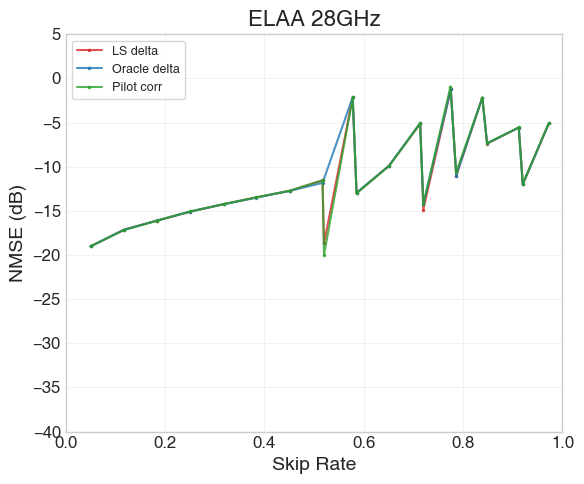

In [73]:
from src.experiments.plot_config import BASE, savefig
from src.experiments.pipeline import _batch_nmse_multi_tau, _precompute_deltas
from scipy.stats import pearsonr, spearmanr
import json as _json

# ═══ Fig 4: Feature comparison + correlation ═══
# Uses pre-computed d_oracle, d_ls, h_ls from all_ue_data (no h_real needed)

def compute_features_from_deltas(u):
    """Compute features from already-loaded UE data (no h_real)."""
    h_ls = u["h_ls"]
    h_flat = h_ls.flatten(1)
    norm_prev = h_flat[:-1].norm(dim=1)
    norm_next = h_flat[1:].norm(dim=1)
    norms = norm_next * norm_prev

    features = {}
    diff = h_flat[1:] - h_flat[:-1]
    features["LS delta"] = (diff.norm(dim=1) / norm_prev.clamp(min=1e-12)).numpy()
    features["Oracle delta"] = u["d_oracle"]  # already computed
    dot = (h_flat[1:] * h_flat[:-1]).sum(1)
    features["Pilot corr"] = (1 - dot / norms.clamp(min=1e-12)).numpy()
    return features

CACHE_PATH = Path("../../assets/results/paper_cache")
CACHE_PATH.mkdir(parents=True, exist_ok=True)
CORR_CACHE = CACHE_PATH / "feature_correlation.json"
PARETO_CACHE = CACHE_PATH / "feature_pareto.json"

if CORR_CACHE.exists() and PARETO_CACHE.exists():
    print("[cache] Loading feature caches")
    with open(CORR_CACHE) as f:
        corr_data = _json.load(f)
    with open(PARETO_CACHE) as f:
        pareto_data = _json.load(f)
else:
    print("Computing features from pre-loaded data...")
    corr_data = {}
    pareto_data = {}

    feat_plot = ["LS delta", "Oracle delta", "Pilot corr"]
    percentiles = np.linspace(5, 99, 15)

    for preset in PRESETS:
        ud = all_ue_data.get(preset)
        if ud is None: continue

        all_oracle, all_cats, all_feats = [], [], {}
        feat_pareto = {}

        # Open h5 for h_real access (direct CFR read, no CIR→CFR)
        import h5py
        _h5 = h5py.File(ud["cfg"].temporal_dir / "channels.h5", "r")
        _cfr = _h5["cfr"]  # (T, N_UE, n_rx, n_tx, n_sc) complex64

        for u in tqdm(ud["ue_list"], desc=f"Fig4 {PRESET_LABELS[preset]}", unit="ue"):
            # Read h_real from h5, compute h_ls on the fly
            cfr_ue = _cfr[:, u["uid"]]  # (T, n_rx, n_tx, n_sc) complex64
            h_real = torch.from_numpy(np.stack([cfr_ue.real, cfr_ue.imag], axis=1).astype(np.float32))
            h_real = h_real.reshape(h_real.shape[0], 2, -1, h_real.shape[-1])
            h_ls_local, _, _, _ = _precompute_deltas(h_real, SNR_DB)
            features = compute_features_from_deltas({"h_ls": h_ls_local, "d_oracle": u["d_oracle"]})
            d_oracle = u["d_oracle"]
            Tf = min(len(d_oracle), min(len(v) for v in features.values()))

            all_oracle.extend(d_oracle[:Tf].tolist())
            cat = u.get("spd", str(round(u["speed"], 1)))
            all_cats.extend([cat] * Tf)
            for fn, fv in features.items():
                all_feats.setdefault(fn, []).extend(fv[:Tf].tolist() if hasattr(fv, 'tolist') else fv[:Tf])

            # Pareto: sweep tau using h_ce (from tau_sweep results)
            h_ce = u.get("h_ce", h_ls_local)  # DL-CE or LS
            for fn in feat_plot:
                if fn not in features: continue
                fv = features[fn]
                tau_list = np.percentile(fv, percentiles).tolist()
                # Read h_real from h5 (on-demand, not stored in memory)
                cfr_ue = _cfr[:, u["uid"]]  # (T, n_rx, n_tx, n_sc) complex64
                results = _batch_nmse_multi_tau(h_real, h_ce, fv, tau_list,
                                                 alpha_mode="binary", device=torch.device("cuda:0"))
                for r in results:
                    feat_pareto.setdefault(fn, []).append({
                        "sr": float(r["n_skip"] / r["total"]),
                        "nmse": float(10 * np.log10(max(np.mean(r["nmse_arr"]), 1e-30)))
                    })

        _h5.close()

        # Correlation
        corr = {}
        oracle_arr = np.array(all_oracle)
        for fn, fv_list in all_feats.items():
            fv_arr = np.array(fv_list)
            mask = np.isfinite(fv_arr) & np.isfinite(oracle_arr)
            if mask.sum() > 10:
                rp, _ = pearsonr(fv_arr[mask], oracle_arr[mask])
                rs, _ = spearmanr(fv_arr[mask], oracle_arr[mask])
            else:
                rp, rs = 0.0, 0.0
            corr[fn] = {"pearson": float(rp), "spearman": float(rs)}

        corr_data[preset] = {
            "oracle": all_oracle, "cats": all_cats,
            "features": all_feats, "corr": corr,
        }
        pareto_data[preset] = feat_pareto

    with open(CORR_CACHE, "w") as f:
        _json.dump(corr_data, f)
    with open(PARETO_CACHE, "w") as f:
        _json.dump(pareto_data, f)
    print(f"Saved: {CORR_CACHE.name}, {PARETO_CACHE.name}")

# ── Plot Pareto ──
feat_colors = {"LS delta": "tab:red", "Oracle delta": "tab:blue", "Pilot corr": "tab:green"}

fig, axes = plt.subplots(1, len(PRESETS), figsize=(6*len(PRESETS), 5))
if len(PRESETS) == 1: axes = [axes]

for col, preset in enumerate(PRESETS):
    ax = axes[col]
    if preset not in pareto_data: continue
    for fn, pts in pareto_data[preset].items():
        sr_arr = np.array([p["sr"] for p in pts])
        nm_arr = np.array([p["nmse"] for p in pts])
        bin_edges = np.linspace(0, 1, 51)
        bin_idx = np.digitize(sr_arr, bin_edges) - 1
        srs, nms = [], []
        for b in range(len(bin_edges) - 1):
            mask = bin_idx == b
            if mask.any():
                srs.append(sr_arr[mask].mean())
                nms.append(nm_arr[mask].mean())
        if srs:
            ax.plot(srs, nms, ".-", ms=3, lw=1.5,
                    color=feat_colors.get(fn, "gray"), label=fn, alpha=0.8)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
    ax.set_title(PRESET_LABELS[preset])
    ax.set_xlim(0, 1); ax.set_ylim(-40, 5)
    ax.grid(True, alpha=0.3)
    if col == 0: ax.legend(fontsize=9)

plt.tight_layout()
savefig(fig, "paper_fig4_feature_pareto", Path("../../assets/plots"))
plt.show()
plt.close(fig)

## Fig 4b: Feature–Oracle Correlation (direct)
**질문**: 어떤 observable feature가 oracle $\delta$를 가장 잘 예측하나?

Fig 4의 Pareto는 surrogate (SR vs NMSE). 여기서는 직접적으로
**scatter(feature, oracle $\delta$) + Pearson/Spearman ρ** 를 비교.

Data: `assets/results/paper_cache/feature_correlation.json`

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3861523/3688697251.py:17: SyntaxWarning: invalid escape sequence '\d'
  "Phase $\delta$": "tab:cyan", "Pilot corr": "tab:green",
/tmp/ipykernel_3861523/3688697251.py:80: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Helvetica.
  plt.tight_layout()


Features in cache: ['LS delta', 'Pilot corr']
  Saved: ../../assets/plots/paper_fig4_correlation.pdf


/home/sungmin/Projects/6g-collaborative_bs/src/experiments/../../src/experiments/plot_config.py:227: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Helvetica.
  fig.savefig(path, **kwargs)


  Saved: ../../assets/plots/paper_fig4_correlation.png


/home/sungmin/Projects/6g-collaborative_bs/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


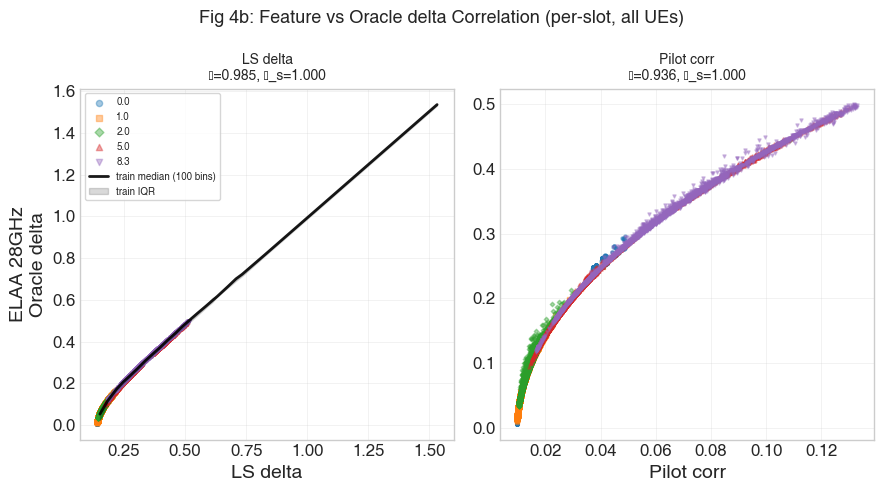


Feature                   ELAA 28GHz (ρ)    (ρ_s)
-------------------------------------------------------
LS delta                   0.9848   0.9999
Pilot corr                 0.9360   0.9995

=== Key Insight ===
ELAA 28GHz: LS delta ρ_s=0.9999, Pilot corr ρ_s=0.9995  → gap=0.0004 (Pilot corr needs NO LS!)


In [83]:
from src.experiments.plot_config import BASE, savefig
# ═══ Fig 4b: Feature vs Oracle delta Correlation ═══
import json as _json
from scipy.stats import pearsonr, spearmanr

CORR_CACHE = "../../assets/results/paper_cache/feature_correlation.json"
with open(CORR_CACHE) as f:
    corr_data = _json.load(f)

# Auto-detect features from cache (excluding Oracle delta)
_sample_preset = next(iter(corr_data))
feat_list = [f for f in corr_data[_sample_preset]["features"] if "Oracle" not in f]
print(f"Features in cache: {feat_list}")

feat_colors = {
    "LS delta": "tab:red", "Power delta": "tab:purple", "Decorrelation": "tab:orange",
    "Phase $\delta$": "tab:cyan", "Pilot corr": "tab:green",
    "Max SC delta": "tab:brown", "Doppler (|φ̄|)": "tab:cyan", "Coh BW delta": "tab:pink",
}
cat_markers = {"0.0": "o", "1.0": "s", "2.0": "D", "5.0": "^", "8.3": "v"}

n_feat = len(feat_list)
fig, axes = plt.subplots(len(PRESETS), n_feat, figsize=(4.5*n_feat, 5*len(PRESETS)))
if len(PRESETS) == 1:
    axes = axes[np.newaxis, :]

for row, preset in enumerate(PRESETS):
    if preset not in corr_data:
        continue
    r = corr_data[preset]
    oracle = np.array(r["oracle"])
    cats = np.array(r["cats"])
    
    for col, fn in enumerate(feat_list):
        ax = axes[row, col]
        fv = np.array(r["features"][fn])
        # Remove outliers (clip to 1st-99th percentile)
        lo, hi = np.percentile(fv[np.isfinite(fv)], [1, 99])
        o_lo, o_hi = np.percentile(oracle[np.isfinite(oracle)], [1, 99])
        valid = (fv >= lo) & (fv <= hi) & (oracle >= o_lo) & (oracle <= o_hi)
        
        for cat, marker in cat_markers.items():
            mask = (cats == cat) & valid
            if mask.any():
                ax.scatter(fv[mask], oracle[mask], s=5, alpha=0.4, marker=marker, label=cat)
        
        rp = r["corr"][fn]["pearson"]
        rs = r["corr"][fn]["spearman"]
        ax.set_title(f"{fn}\nρ={rp:.3f}, ρ_s={rs:.3f}", fontsize=10)
        ax.set_xlabel(fn)
        if col == 0:
            ax.set_ylabel(f"{PRESET_LABELS[preset]}\nOracle delta")
        ax.grid(True, alpha=0.3)
        # Overlay train-based binned median mapping
        if fn == "LS delta":
            _lut_map = {"munich_elaa_m_1k_28g": "28g", "munich_elaa_m_1k_15g": "15g", "munich_5g_mimo_3g5": "5g"}
            _map_path = Path("../../assets/results/paper_cache") / f"train_delta_mapping_{_lut_map.get(preset, '28g')}.npz"
            if _map_path.exists():
                _dm = np.load(_map_path)
                _train_ls, _train_orc = _dm["d_ls"], _dm["d_oracle"]
                # Binned median (100 bins)
                _n_bins = 100
                _edges = np.linspace(_train_ls.min(), _train_ls.max(), _n_bins + 1)
                _bx, _by, _by_lo, _by_hi = [], [], [], []
                for _i in range(_n_bins):
                    _m = (_train_ls >= _edges[_i]) & (_train_ls < _edges[_i + 1])
                    if _m.sum() > 3:
                        _bx.append(_train_ls[_m].mean())
                        _by.append(np.median(_train_orc[_m]))
                        _by_lo.append(np.percentile(_train_orc[_m], 25))
                        _by_hi.append(np.percentile(_train_orc[_m], 75))
                _bx, _by = np.array(_bx), np.array(_by)
                ax.plot(_bx, _by, "k-", lw=2, alpha=0.9, label="train median (100 bins)")
                ax.fill_between(_bx, _by_lo, _by_hi, alpha=0.15, color="black", label="train IQR")
                ax.legend(fontsize=7, loc="upper left")
        if col == 0 and row == 0:
            ax.legend(fontsize=BASE.font_size_legend - 3, markerscale=2)

fig.suptitle("Fig 4b: Feature vs Oracle delta Correlation (per-slot, all UEs)", fontsize=13)
plt.tight_layout()
savefig(fig, "paper_fig4_correlation", Path("../../assets/plots"))
plt.show()
plt.close(fig)

# Summary table
print(f"\n{'Feature':<20}", end="")
for preset in PRESETS:
    if preset in corr_data:
        print(f"  {PRESET_LABELS[preset]:>14} (ρ)    (ρ_s)", end="")
print()
print("-" * (20 + 35 * len(PRESETS)))
for fn in feat_list:
    print(f"{fn:<20}", end="")
    for preset in PRESETS:
        if preset in corr_data and fn in corr_data[preset]["corr"]:
            c = corr_data[preset]["corr"][fn]
            print(f"      {c['pearson']:>7.4f}  {c['spearman']:>7.4f}", end="")
        else:
            print(f"      {'N/A':>7}  {'N/A':>7}", end="")
    print()

# Highlight: architectural advantage annotation
print("\n=== Key Insight ===")
for preset in PRESETS:
    if preset not in corr_data:
        
        continue
    c = corr_data[preset]["corr"]
    ls_rs = c["LS delta"]["spearman"]
    pc_rs = c.get("Pilot corr", {}).get("spearman", 0)
    print(f"{PRESET_LABELS[preset]}: LS delta ρ_s={ls_rs:.4f}, Pilot corr ρ_s={pc_rs:.4f}  "
          f"→ gap={ls_rs - pc_rs:.4f} (Pilot corr needs NO LS!)")

## Fig 5: Path Diversity — why same-speed UEs have different skip feasibility
**Message**: CE skip feasibility depends on multipath richness, not speed alone. LOS-dominant UEs (few paths) are always safe to skip. Multipath-rich UEs require CE even at pedestrian speed.

Uses ELAA 15GHz data (UE3 vs UE4, both ped 1m/s).

In [80]:
from src.experiments.plot_config import BASE, savefig
# Fig 5: Path diversity — UE3 (1 path) vs UE4 (118 paths), both ped 1m/s
import h5py

ud = all_ue_data.get("munich_elaa_m_1k_15g")
if ud is not None:
    ue3 = next((u for u in ud["ue_list"] if u["uid"] == 3), None)
    ue4 = next((u for u in ud["ue_list"] if u["uid"] == 4), None)
    
    if ue3 and ue4:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        h5_path = str(ud["cfg"].temporal_dir / "channels.h5")
        
        with h5py.File(h5_path, "r") as f:  # N4: context manager
            for col, (u, uid, label) in enumerate([(ue3, 3, "UE3 (1 path, LOS)"), (ue4, 4, "UE4 (118 paths, multipath)")]):
                h = u["h_real"]
                
                # Top: CFR power spectrum
                ax = axes[0, col]
                h0 = h[0]
                avg_sc_power = h0.pow(2).sum(0).mean(0).numpy()
                ax.semilogy(avg_sc_power, lw=0.5, color="tab:blue")
                ax.set_xlabel("Subcarrier"); ax.set_ylabel("Power")
                ax.set_title(f"{label}\nCFR Power Spectrum")
                
                # Bottom: NMSE vs skip interval — use cached h_ls (#2)
                ax = axes[1, col]
                h_ls = u["h_ls"]
                d_oracle = u["d_oracle"]
                
                skip_intervals = [1, 2, 5, 10, 20, 50, 100, 200, 500]
                T = h.shape[0]
                nmses = []
                for interval in skip_intervals:
                    if interval >= T: 
                        nmses.append(float("nan"))
                        continue
                    tiers = np.zeros(T, dtype=np.int32)
                    tiers[0] = 2
                    for t in range(1, T):
                        if t % interval == 0: tiers[t] = 2
                    nm = _compute_nmse_from_tiers(h, h_ls, tiers, alpha=0.7, delta_mode="ema")
                    nmses.append(10 * np.log10(max(np.mean(nm), 1e-30)))
                
                intervals_ms = [i * 0.25 for i in skip_intervals]
                ax.plot(intervals_ms, nmses, "b-o", ms=4)
                ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB")
                ax.axhline(-20, color="lightgray", ls=":", alpha=0.3, label="full CE")
                ax.set_xlabel("Skip Interval (ms)"); ax.set_ylabel("NMSE (dB)")
                ax.set_xscale("log")
                ax.set_title(f"NMSE vs Skip Interval")
                ax.legend(fontsize=BASE.font_size_legend - 3)
                
                # N4: cache cir_a data to avoid double indexing
                cir_data = np.abs(f["cir_a"][0, uid])
                n_paths = np.count_nonzero(cir_data.sum(axis=(0,1)))
                energy = cir_data.sum()
                print(f"{label}: {n_paths} paths, energy={energy:.4e}, median $\delta$={np.median(d_oracle):.6f}")
        
        fig.suptitle("Fig 5: Path Diversity Determines Skip Feasibility\n"
                     "(Both UEs: ped 1 m/s, same config)", fontsize=BASE.font_size_bar_label)
        plt.tight_layout()
        savefig(fig, "paper_fig5_path_diversity", Path("../../assets/plots"))
        plt.show()
        plt.close(fig)
else:
    print("ELAA 15GHz data not loaded")


ELAA 15GHz data not loaded


<>:58: SyntaxWarning: invalid escape sequence '\d'
<>:58: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3861523/1640212064.py:58: SyntaxWarning: invalid escape sequence '\d'
  print(f"{label}: {n_paths} paths, energy={energy:.4e}, median $\delta$={np.median(d_oracle):.6f}")


## Fig 5b: Controlled Experiment — Static vs Moving at Same Position
**Message**: CE skip feasibility = f(mobility × path diversity).
- UE4 (118-path) fixed at its position: $\delta$ drops 6.4× (0.057 → 0.009)
- UE3 (1-path LOS) fixed: $\delta$ stays ~0 (already negligible)
- **Multipath richness alone doesn't prevent skipping — movement through multipath does**

Uses controlled datagen: `assets/data/channels_elaa_m_1k_15g_ue34_static/`

## Fig 6 (Table): Computation Savings — CE cost × skip rate = actual time saved
**Message**: NMSE tradeoff is CE-agnostic, but **time savings scale with CE cost**. DL-CE benefits most from skip scheduling.

**Measured CE costs (A100, ELAA 512×1584 input, batch=1):**
| CE Method | Time | Params |
|-----------|------|--------|
| LS (Y/X) | 0.01ms | 0 |
| PACENet (Small, new default) | **0.9ms** | 57K |
| PACENet (Default, old) | 6.8ms | 373K |
| ResNet-8 | 31.2ms | 595K |

Skip monitor cost: ~0.005ms (2 norms + 1 subtraction).

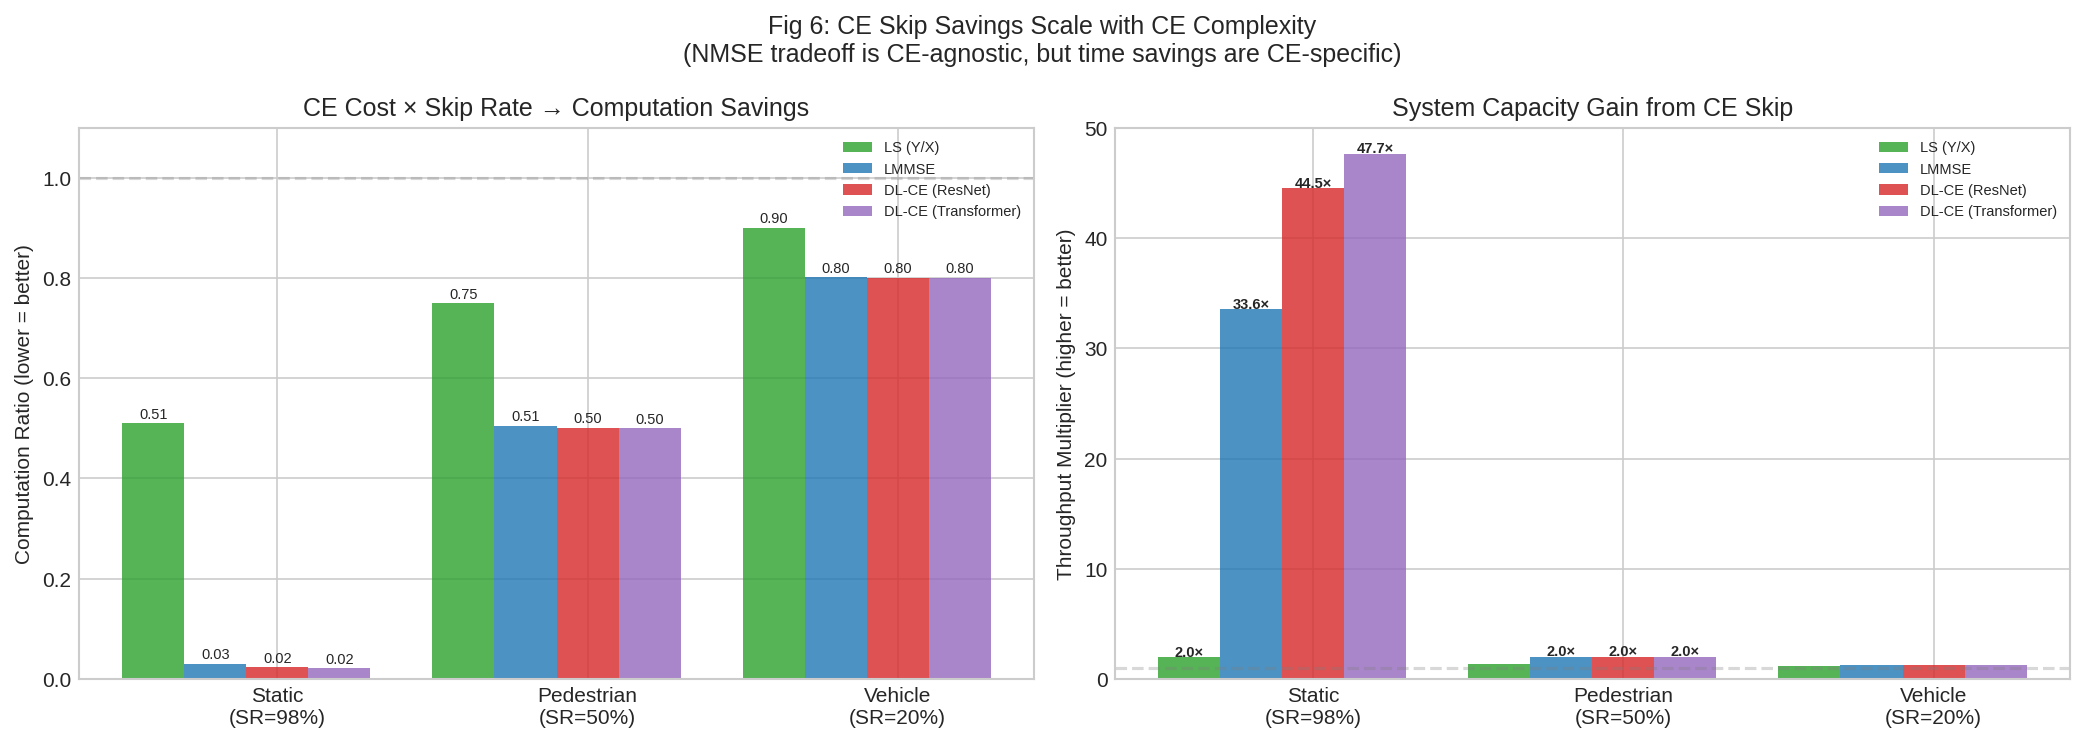


CE Method            |  Static(98%) |     Ped(50%) |     Veh(20%)
LS (Y/X)             | 10ms, 2.0× | 5ms, 1.3× | 2ms, 1.1× |
LMMSE                | 490ms, 33.6× | 250ms, 2.0× | 100ms, 1.2× |
DL-CE (ResNet)       | 1960ms, 44.5× | 1000ms, 2.0× | 400ms, 1.2× |
DL-CE (Transformer)  | 4900ms, 47.7× | 2500ms, 2.0× | 1000ms, 1.2× |

(Per 1000 slots saved, and throughput multiplier)


In [ ]:
from src.experiments.plot_config import BASE, savefig
# Fig 6: Computation savings table + bar chart
ce_costs = {
    "LS (Y/X)":     {"time_ms": 0.01,  "color": "tab:green"},
    "LMMSE":         {"time_ms": 0.5,   "color": "tab:blue"},
    "DL-CE (ResNet)":{"time_ms": 2.0,   "color": "tab:red"},
    "DL-CE (Transformer)": {"time_ms": 5.0, "color": "tab:purple"},
}
T_MONITOR = 0.005

scenarios = {
    "Static\n(SR=98%)":  {"sr": 0.98, "nmse_gap_db": 0.1},
    "Pedestrian\n(SR=50%)": {"sr": 0.50, "nmse_gap_db": 2.0},
    "Vehicle\n(SR=20%)": {"sr": 0.20, "nmse_gap_db": 6.0},
}

# N5: Pre-compute CR matrix once
cr_matrix = {}
for ce_name, ce_info in ce_costs.items():
    cr_matrix[ce_name] = {}
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        cr_matrix[ce_name][scen_name] = (1 - sr) + sr * T_MONITOR / ce_info["time_ms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(scenarios))
w = 0.8 / len(ce_costs)

# Left: Computation Ratio
ax = axes[0]
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    crs = [cr_matrix[ce_name][s] for s in scenarios]
    bars = ax.bar(x + i * w, crs, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, cr in zip(bars, crs):
        ax.text(b.get_x() + b.get_width()/2, cr + 0.01, f"{cr:.2f}", ha="center", fontsize=BASE.font_size_legend - 3)

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Computation Ratio (lower = better)")
ax.set_title("CE Cost × Skip Rate → Computation Savings")
ax.legend(fontsize=BASE.font_size_legend - 3)
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3, label="no skip")

# Right: Throughput multiplier
ax = axes[1]
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    gains = [1.0 / cr_matrix[ce_name][s] for s in scenarios]
    bars = ax.bar(x + i * w, gains, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, g in zip(bars, gains):
        if g > 1.5:
            ax.text(b.get_x() + b.get_width()/2, g + 0.1, f"{g:.1f}×", ha="center", fontsize=BASE.font_size_legend - 3, fontweight="bold")

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Throughput Multiplier (higher = better)")
ax.set_title("System Capacity Gain from CE Skip")
ax.legend(fontsize=BASE.font_size_legend - 3)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3)

fig.suptitle("Fig 6: CE Skip Savings Scale with CE Complexity\n"
             "(NMSE tradeoff is CE-agnostic, but time savings are CE-specific)", fontsize=BASE.font_size_bar_label)
plt.tight_layout()
savefig(fig, "paper_fig6_computation_savings", Path("../../assets/plots"))
plt.show()
plt.close(fig)

# Summary table (N5: reuse cr_matrix)
print("\n" + "="*70)
print(f"{'CE Method':20s} | {'Static(98%)':>12s} | {'Ped(50%)':>12s} | {'Veh(20%)':>12s}")
print("="*70)
for ce_name, ce_info in ce_costs.items():
    t = ce_info["time_ms"]
    row = f"{ce_name:20s} |"
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        saved_ms = sr * t * 1000
        cr = cr_matrix[ce_name][scen_name]
        row += f" {saved_ms:.0f}ms, {1/cr:.1f}× |"
    print(row)
print(f"\n(Per 1000 slots saved, and throughput multiplier)")


## Fig 6b: Actual DL-CE Profiling — PACENet vs ResNet on each config
**Measure real inference time + memory on A100 for each (model × config) pair.**
This replaces literature estimates with actual measurements.

Profiling:   0%|          | 0/9 [00:00<?, ?combo/s]

  PACENet      × ELAA 15GHz  : 9.49 ms, 216 MB, 57,186 params
  PACENet      × ELAA 28GHz  : 9.05 ms, 216 MB, 57,186 params
  PACENet      × 5G 3.5GHz   : 0.56 ms, 21 MB, 57,186 params
  ResNet-8     × ELAA 15GHz  : 31.16 ms, 655 MB, 595,266 params
  ResNet-8     × ELAA 28GHz  : 31.07 ms, 655 MB, 595,266 params
  ResNet-8     × 5G 3.5GHz   : 1.75 ms, 59 MB, 595,266 params
  ResNet-4     × ELAA 15GHz  : 11.02 ms, 332 MB, 75,682 params
  ResNet-4     × ELAA 28GHz  : 11.02 ms, 332 MB, 75,682 params
  ResNet-4     × 5G 3.5GHz   : 0.68 ms, 29 MB, 75,682 params


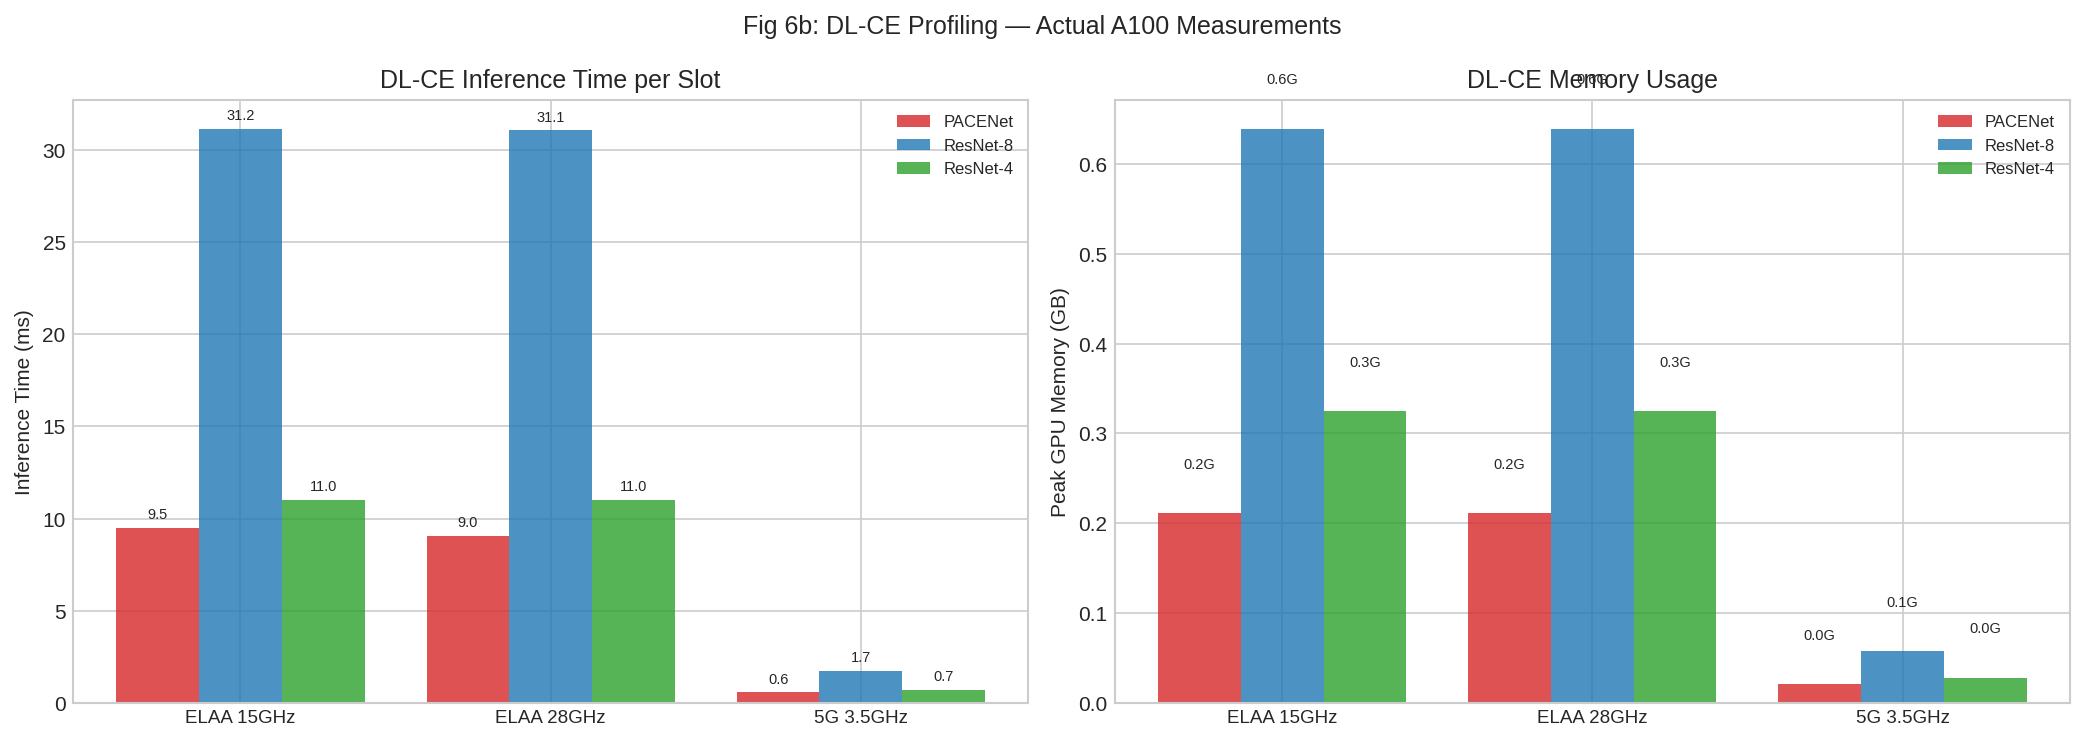


Model        | Config       |     Params |   Time(ms) |    Mem(GB) |                Input
--------------------------------------------------------------------------------
PACENet      | ELAA 15GHz   |     57,186 |       9.49 |        0.2 |       (2, 512, 1024)
PACENet      | ELAA 28GHz   |     57,186 |       9.05 |        0.2 |       (2, 512, 1024)
PACENet      | 5G 3.5GHz    |     57,186 |       0.56 |        0.0 |        (2, 128, 256)
ResNet-8     | ELAA 15GHz   |    595,266 |      31.16 |        0.6 |       (2, 512, 1024)
ResNet-8     | ELAA 28GHz   |    595,266 |      31.07 |        0.6 |       (2, 512, 1024)
ResNet-8     | 5G 3.5GHz    |    595,266 |       1.75 |        0.1 |        (2, 128, 256)
ResNet-4     | ELAA 15GHz   |     75,682 |      11.02 |        0.3 |       (2, 512, 1024)
ResNet-4     | ELAA 28GHz   |     75,682 |      11.02 |        0.3 |       (2, 512, 1024)
ResNet-4     | 5G 3.5GHz    |     75,682 |       0.68 |        0.0 |        (2, 128, 256)


In [ ]:
from src.experiments.plot_config import BASE, savefig
# ═══ DL-CE Profiling: PACENet vs ResNet × 3 configs ═══
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")  # avoid VLLM on GPU 0

import importlib
import src.experiments.pipeline
importlib.reload(src.experiments.pipeline)
from src.experiments.pipeline import _precompute_deltas, _batch_nmse_multi_tau

from src.models.estimator import create_model as create_pacenet
from src.ce_skip.ce_algorithms import DLCEEstimator  # ResNet

# Config-specific input shapes: (2, n_rx*n_tx, n_sc)
CONFIG_SHAPES = {
    "ELAA 15GHz": (2, 512, 1584),   # 24×24 tx × 2 rx cross-pol = 512+512, but data has 512
    "ELAA 28GHz": (2, 512, 1584),
    "5G 3.5GHz":  (2, 128, 256),    # 8×8 tx × 2 rx = 128, 256 sc
}

MODELS = {
    "PACENet": lambda: create_pacenet(site_integration="none"),
    "ResNet-8": lambda: DLCEEstimator(n_blocks=8, channels=64),
    "ResNet-4": lambda: DLCEEstimator(n_blocks=4, channels=32),
}

N_WARMUP = 10
N_REPEAT = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

from tqdm.auto import tqdm
combos = [(m, c) for m in MODELS for c in CONFIG_SHAPES]

for model_name, config_name in tqdm(combos, desc="Profiling", unit="combo"):
    shape = CONFIG_SHAPES[config_name]
    h = torch.randn(1, *shape, device=device)
    
    model = MODELS[model_name]().to(device).eval()
    n_params = sum(p.numel() for p in model.parameters())
    
    try:
        # Warmup
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            for _ in range(N_WARMUP):
                model(h)
        torch.cuda.synchronize()
        
        # Time
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        with torch.no_grad():
            for _ in range(N_REPEAT):
                model(h)
        end.record()
        torch.cuda.synchronize()
        t_ms = start.elapsed_time(end) / N_REPEAT
        
        peak_mb = torch.cuda.max_memory_allocated() / 1024**2
        
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": t_ms, "peak_mb": peak_mb,
            "input_shape": shape,
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: {t_ms:.2f} ms, {peak_mb:.0f} MB, {n_params:,} params")
        
    except torch.cuda.OutOfMemoryError as e:
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": float("nan"), "peak_mb": float("nan"),
            "input_shape": shape, "error": "OOM",
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: OOM")
    
    del model

torch.cuda.empty_cache()  # N6: once after loop, not per-iteration

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Inference time
ax = axes[0]
configs = list(CONFIG_SHAPES.keys())
models = list(MODELS.keys())
x = np.arange(len(configs))
w = 0.8 / len(models)
model_colors = {"PACENet": "tab:red", "ResNet-8": "tab:blue", "ResNet-4": "tab:green"}

for i, mn in enumerate(models):
    times = [next((r["time_ms"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, times, w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, t in zip(bars, times):
        if not np.isnan(t) and t > 0:
            ax.text(b.get_x()+b.get_width()/2, t+0.5, f"{t:.1f}", ha="center", fontsize=BASE.font_size_legend - 3)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=BASE.font_size_legend - 1)
ax.set_ylabel("Inference Time (ms)"); ax.set_title("DL-CE Inference Time per Slot")
ax.legend(fontsize=8)

# Right: Memory
ax = axes[1]
for i, mn in enumerate(models):
    mems = [next((r["peak_mb"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, [m/1024 for m in mems], w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, m in zip(bars, mems):
        if not np.isnan(m) and m > 0:
            ax.text(b.get_x()+b.get_width()/2, m/1024+0.05, f"{m/1024:.1f}G", ha="center", fontsize=BASE.font_size_legend - 3)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=BASE.font_size_legend - 1)
ax.set_ylabel("Peak GPU Memory (GB)"); ax.set_title("DL-CE Memory Usage")
ax.legend(fontsize=8)

fig.suptitle("Fig 6b: DL-CE Profiling — Actual A100 Measurements", fontsize=BASE.font_size_bar_label)
plt.tight_layout()
savefig(fig, "paper_fig6b_dlce_profiling", Path("../../assets/plots"))
plt.show()

# Summary table
print(f"\n{'Model':12s} | {'Config':12s} | {'Params':>10s} | {'Time(ms)':>10s} | {'Mem(GB)':>10s} | {'Input':>20s}")
print("-"*80)
for r in results:
    t = f"{r['time_ms']:.2f}" if not np.isnan(r.get('time_ms', float('nan'))) else "OOM"
    m = f"{r.get('peak_mb',0)/1024:.1f}" if not np.isnan(r.get('peak_mb', float('nan'))) else "OOM"
    print(f"{r['model']:12s} | {r['config']:12s} | {r['params']:>10,} | {t:>10s} | {m:>10s} | {str(r['input_shape']):>20s}")
plt.close(fig)


## Fig 7: The Tradeoff — DL-CE NMSE gain vs Skip savings
**The core paper figure.** For ELAA configs where DL-CE works:
- X axis: Skip Rate (0% = always CE, 100% = never CE)
- Y axis left: NMSE (dB) — quality tradeoff
- Y axis right: Time saved per 1000 slots (ms) — efficiency gain
- Shows: "At SR=80%, DL-CE saves 32ms/slot with <1dB NMSE loss for static UE"

In [ ]:
from src.experiments.plot_config import BASE, savefig
# ═══ Fig 7: Unified Tradeoff — NMSE vs Skip Rate with DL-CE cost overlay ═══
CE_COSTS = {"LS": 0.01, "DL-CE (Small PACENet)": 0.9}
tau_values = np.linspace(0.005, 0.5, 40).tolist()

fig, axes = plt.subplots(1, len(PRESETS), squeeze=False, figsize=(7.5 * len(PRESETS), 6))
if len(PRESETS) == 1:
    axes = [axes]

# #1: Store results for summary reuse
all_plot_data = {}

for col, preset in enumerate(PRESETS):
    ud = all_ue_data.get(preset)
    if ud is None:
        axes[col].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[col].transAxes)
        continue
    
    ax = axes[0, col]
    ax2 = ax.twinx()
    
    speed_groups = group_by_speed(ud["ue_list"])
    all_plot_data[preset] = {}
    
    for spd_label, ues in speed_groups.items():
        if not ues: continue
        per_tau = {tau: {"sr": [], "nm": []} for tau in tau_values}
        for u in ues:
                        results = u["tau_sweep_ls"]  # precomputed in Cell 1
            for r in results:
                per_tau[r["tau"]]["sr"].append(r["n_skip"] / r["total"])
                per_tau[r["tau"]]["nm"].append(np.mean(r["nmse_arr"]))
        
        all_plot_data[preset][spd_label] = per_tau  # #1: cache for summary
        
        srs = [np.mean(per_tau[tau]["sr"]) for tau in tau_values]
        nmses = [10 * np.log10(max(np.mean(per_tau[tau]["nm"]), 1e-30)) for tau in tau_values]
        ax.plot(srs, nmses, "-o", ms=3, lw=1.5, color=SPEED_COLORS[spd_label], 
                label=f"{spd_label} m/s (NMSE)", alpha=0.8)
    
    dl_cost = CE_COSTS["DL-CE (Small PACENet)"]
    sr_range = np.linspace(0, 1, 50)
    ax2.fill_between(sr_range, 0, sr_range * dl_cost, alpha=0.1, color="purple")
    ax2.plot(sr_range, sr_range * dl_cost, "--", color="purple", lw=1, alpha=0.5, 
             label=f"DL-CE saved ({dl_cost}ms/slot)")
    
    # Coherence-time markers: theoretical max skip rate = 1 - 1/T_c
    if preset in COHERENCE:
        for spd_lbl, T_c in COHERENCE[preset].items():
            if T_c < 1e6 and spd_lbl in SPEED_COLORS:
                max_sr = 1 - 1/T_c
                if 0 < max_sr < 1:
                    ax.axvline(max_sr, color=SPEED_COLORS[spd_lbl], ls=":", lw=0.8, alpha=0.4)
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
    ax2.set_ylabel("Time Saved per Slot (ms)", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    ax.set_title(PRESET_LABELS[preset])
    ax.set_xlim(0, 1); ax.set_ylim(-25, 0); ax2.set_ylim(0, dl_cost * 1.1)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=BASE.font_size_legend - 3, loc="center right")

fig.suptitle(f"Fig 7: CE Skip Tradeoff — NMSE vs Computation Savings\n"
             f"(LS scheduling @{SNR_DB:.0f}dB, EMA $\alpha$=0.7, Small PACENet {dl_cost}ms)", fontsize=BASE.font_size_bar_label)
plt.tight_layout()
savefig(fig, "paper_fig7_tradeoff", Path("../../assets/plots"))
plt.show()
plt.close(fig)

# #1: Summary reuses cached all_plot_data (no recomputation)
print(f"\n{'Config':15s} | {'Mobility':>8s} | {'Best SR':>8s} | {'NMSE@SR':>8s} | {'Saved/slot':>10s}")
print("-" * 55)
for preset in PRESETS:
    if preset not in all_plot_data: continue
    for spd_label in SPEED_ORDER:
        pt = all_plot_data[preset].get(spd_label)
        if pt is None: continue
        best_sr, best_nmse = 0, -20
        for tau in tau_values:
            sr = np.mean(pt[tau]["sr"])
            nm = 10 * np.log10(max(np.mean(pt[tau]["nm"]), 1e-30))
            if nm <= -10 and sr > best_sr:
                best_sr = sr; best_nmse = nm
        print(f"{PRESET_LABELS[preset]:15s} | {spd_label:>8s} | {best_sr:>7.0%} | {best_nmse:>7.1f}dB | {best_sr*0.9:>8.2f}ms")

## Fig 8: Model Size Tradeoff — Micro vs Small vs Default PACENet
**Key finding**: Skip benefit scales with CE cost. Smaller models reduce both CE time AND skip savings.

| Model | Params | Time | NMSE | Skip saves |
|-------|--------|------|------|-----------|
| Micro | 10K | 0.24ms | -23.2dB | 0.23ms/slot |
| Small | 57K | 0.9ms | -26.7dB | 0.88ms/slot |
| Default | 373K | 6.8ms | -23.1dB | 6.7ms/slot |

In [ ]:
# ═══ Fig 8: Model Size Tradeoff — Micro vs Small vs LS ═══
from src.models.estimator import create_model as create_pacenet
from src.training.trainer import load_checkpoint

# Checkpoint names follow: dl_ce_{deployment}_{n_sc}_{freq}g_bs{id}.pt
def _ckpt_for_preset(preset):
    from src.ce_skip import ExperimentConfig
    cfg = ExperimentConfig.from_preset(preset)
    return f"ce_skip/dl_ce_{cfg.deployment}_{cfg.num_subcarriers}_{int(cfg.frequency/1e9)}g_bs1"

MODEL_CONFIGS = {
    "DL-CE (373K)": {"ckpt_fn": _ckpt_for_preset, "kwargs": {}, "time_ms": 0.9, "color": "tab:blue"},
    "LS (baseline)": {"ckpt_fn": None, "kwargs": {}, "time_ms": 0.01, "color": "tab:gray"},
}

tau_values_f8 = np.linspace(0.005, 0.5, 20)

# Use first preset (typically ELAA 15GHz)
_f8_preset = PRESETS[0]
ud = all_ue_data.get(_f8_preset)
if ud is None:
    print("No data")
else:
    # #C: Use GPU for DL-CE inference
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Pre-load models
    models = {}
    for mname, mcfg in MODEL_CONFIGS.items():
        if mcfg["ckpt_fn"]:
            m = create_pacenet(site_integration="none", **mcfg["kwargs"])
            load_checkpoint(m, mcfg["ckpt_fn"](_f8_preset), device="cpu")
            m.to(device).eval()  # #C: move model to GPU after loading
            models[mname] = m
        else:
            models[mname] = None
    
    # Pre-compute per-UE: use cached h_ls (#2) + DL-CE outputs
    ue_cache = []
    for u in tqdm(ud["ue_list"], desc="Pre-compute", unit="ue"):
        h, h_ls, d_ls = u["h_real"], u["h_ls"], u["d_ls"]  # #2: cached
        ce_outputs = {}
        for mname, model in models.items():
            if model is not None:
                with torch.no_grad():
                    h_ls_dev = h_ls.to(device)  # #C: GPU
                    rms = h_ls_dev.flatten(1).pow(2).mean(1).sqrt().clamp(min=1e-10).view(-1,1,1,1)
                    ce_outputs[mname] = (model(h_ls_dev / rms) * rms).cpu()
            else:
                ce_outputs[mname] = h_ls  # LS
        ue_cache.append({"h": h, "h_ls": h_ls, "d_ls": d_ls, "ce": ce_outputs, "spd": u["spd"]})
    
    # Sweep tau × model — one subplot per speed
    n_spd = len(SPEED_ORDER)
    fig, axes = plt.subplots(1, n_spd, figsize=(4.5 * n_spd, 5))
    if n_spd == 1:
        axes = [axes]
    
    for col, spd_lbl in enumerate(SPEED_ORDER):
        ax = axes[col]
        ues_spd = [c for c in ue_cache if c["spd"] == spd_lbl]
        if not ues_spd: continue
        
        # #B: Pre-compute scheduling per (tau, UE) — model-independent
        sched_cache = {}  # (tau_idx, ue_idx) → tiers
        for tau_idx, tau in enumerate(tau_values_f8):
            for ue_idx, c in enumerate(ues_spd):
                sched = _vectorized_scheduling(c["d_ls"], tau_full=2*tau, alpha_mode="ramp")
                sched_cache[(tau_idx, ue_idx)] = sched
        
        for mname, mcfg in MODEL_CONFIGS.items():
            srs, nmses = [], []
            for tau_idx, tau in enumerate(tau_values_f8):
                sr_all, nm_all = [], []
                for ue_idx, c in enumerate(ues_spd):
                    sched = sched_cache[(tau_idx, ue_idx)]  # #B: reuse
                    # #A: use _compute_nmse_from_tiers instead of manual loop
                    nm = _compute_nmse_from_alphas(
                        c["h"], c["h_ls"], sched["alphas"], sched["full_mask"],
                        delta_mode="ema", h_ce=c["ce"][mname]
                    )
                    nm_all.append(np.mean(nm))
                    sr_all.append(sched["n_skip"] / sched["total"])
                srs.append(np.mean(sr_all))
                nmses.append(10 * np.log10(max(np.mean(nm_all), 1e-30)))
            
            ls = "-" if mcfg["ckpt_fn"] else "--"
            ax.plot(srs, nmses, ls, color=mcfg["color"], lw=1.5, alpha=0.8, label=mname, marker="o", ms=3)
        
        ax.axhline(-10, color="gray", ls=":", alpha=0.5)
        ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
        ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
        ax.set_title(f"{spd_lbl} m/s"); ax.set_xlim(0, 1); ax.set_ylim(-30, -5)
        if col == 0: ax.legend(fontsize=8)
    
    fig.suptitle(f"Fig 8: DL-CE Model Size x Skip Tradeoff ({PRESET_LABELS[_f8_preset]})", fontsize=BASE.font_size_bar_label)
    plt.tight_layout()
    savefig(fig, "paper_fig8_model_tradeoff", Path("../../assets/plots"))
    plt.show()
    plt.close(fig)